# Whole-genome sequencing taxonomy classification and detection of antimicrobial resistance genes in oral Streptococcus species

In [5]:
# libraries
library(tidyverse) 
library(readxl)
library(pheatmap)
library(patchwork)
library(RColorBrewer)
library(ggnewscale)
library(rentrez)
library(ggalluvial)
library(ape)
library(ggtree)
library(ggtreeExtra)
library(vegan)
library(phytools)
library(gridExtra)
library(grid)
library(writexl)
library(ggdendro)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ lubridate 1.9.5
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ gridExtra::combine() masks dplyr::combine()
✖ ggtree::expand()     masks tidyr::expand()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::lag()         masks stats::lag()
✖ maps::map()          masks purrr::map()
✖ ape::where()         masks dplyr::where()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Metadata

In [6]:
df <- read_excel("../metadata/strepseq_master_sheet.xlsx")

New names:
• `` -> `...21`
• `` -> `...25`


Metadata statistics - unfiltered

In [7]:
# How many included in the original paper
print("Included in the paper:")
table(df$Included_in_PMID_40182115)

# Resistance zones
zone_stats <- df |>
  transmute(
    Resistance = str_trim(as.character(Resistance)),
    Zone_diameter_raw = as.character(`Zone diameter`)
  ) |>
  mutate(
    # Extract antibiotic name from values like "Clindamycin_resistant"
    antibiotic = str_remove(Resistance, "_resistant$") |> str_to_lower(),
    # Parse zone diameter 
    zone_diameter = suppressWarnings(
      parse_number(str_replace_all(Zone_diameter_raw, ",", ".")))
  ) |>
  filter(!is.na(antibiotic), antibiotic != "", !is.na(zone_diameter)) |>
  group_by(antibiotic) |>
  summarise(
    n = n(),
    min_zone_diameter = min(zone_diameter),
    max_zone_diameter = max(zone_diameter),
    .groups = "drop"
  ) |>
  arrange(antibiotic)

zone_stats

[1] "Included in the paper:"



  ?  NO YES 
 18  16  62 

antibiotic,n,min_zone_diameter,max_zone_diameter
<chr>,<int>,<dbl>,<dbl>
ampicillin,19,0,14
clindamycin,48,0,18
penicillin,10,0,11


Filtering

In [13]:
df |> filter((Genome_sequencing_qc == "Fail") |
                            Exlcude_due_to_uncertainty_about_sample_identity == "EXCLUDE") 

SAMPLE_ID,ZEROPREFIX_SAMPLE_ID,Included_in_PMID_40182115,GM_FILE_ID,Genome_sequencing_qc,Number_contigs_genome,Genome_size,Topmost_percent_Bracken_read_classification,Species_GTDB_release207_ANIpercent,Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc,⋯,Navn,Maldi species 1. test,Maldi species 2. test,Zone diameter,Hvor de kommer fra,...21,gtdb-tk-2.6.1_on_r226,gtdb-tk-2.1.1_on_r214,gtdb-tk-2.1.1_on_r207v2,...25
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>,<lgl>
76p,0076p,?,0076p-CMPN001x86_260114_LH00793_B23GCKKLT3,Fail,186,4138567,Streptococcus parasanguinis (51.86%),No species (%),"tetA(46)_1,tetB(46)_1",⋯,76p,Parasanguinis,Parasanguinis,,Astrid udtaget fra Marias,NA,Unclassified Bacteria,Unclassified Bacteria,Unclassified Bacteria,TRUE
116s,0116s,?,0116s-CMPN001x91_260114_LH00793_B23GCKKLT3,Pass,81,2284047,Streptococcus salivarius (89.37%),Streptococcus salivarius (95.6%),NA,⋯,116s,Salivarius,Salivarius,NA,Astrid udtaget fra Marias,NA,s__Streptococcus salivarius_D,s__Streptococcus salivarius,s__Streptococcus salivarius,TRUE
92Cv,092Cv,YES,092Cv-CMPN001x15_260114_LH00793_B23GCKKLT3,Pass,54,2375309,Streptococcus salivarius (88.3%),Streptococcus sp001556435 (95.9%),"erm(B)_18,lsa(C)_1,mef(A)_2,msr(D)_2,tet(M)_4",⋯,92Cv,Vestibularis,Vestibularis,R11,Marias,NA,s__Streptococcus sp001556435,s__Streptococcus sp001556435,s__Streptococcus sp001556435,TRUE
145Csv,145Csv,NO,145Csv-CMPN001x67_260114_LH00793_B23GCKKLT3,Pass,104,2097367,Streptococcus oralis (36.88%),Streptococcus oralisxK (95.9%),"erm(B)_18,tet(M)_12",⋯,145Csv,Salivarius,Vestibularis,R0,Astrids,NA,s__Streptococcus oralis_K,s__Streptococcus oralis_K,s__Streptococcus oralis_K,TRUE
97Csv,97Csv,YES,97Csv-CMPN001x17_260114_LH00793_B23GCKKLT3,Pass,51,2375249,Streptococcus salivarius (89.37%),Streptococcus sp001556435 (95.9%),"erm(B)_18,lsa(C)_1,mef(A)_2,msr(D)_2,tet(M)_4",⋯,97Csv,Vestibularis,Vestibularis,R0,Marias,NA,s__Streptococcus sp001556435,s__Streptococcus sp001556435,s__Streptococcus sp001556435,TRUE
kontrol,kontrol,NO,CMPN001xneg96-CMPN001xneg96_260114_LH00793_B23GCKKLT3,Fail,EMPTY,EMPTY,EMPTY,EMPTY,EMPTY,⋯,Kontrol,NA,NA,NA,NA,NA,Unclassified,Unclassified,Unclassified,TRUE


In [8]:
df_filtered <- df |>
                    # keep only relevant columns
                     select(c('SAMPLE_ID','GM_FILE_ID','Genome_sequencing_qc',
                            'Number_contigs_genome','Genome_size','Species_GTDB_release207_ANIpercent',
                            'Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc',
                            'Exlcude_due_to_uncertainty_about_sample_identity',
                            'Resistance','Maldi species 2. test', 'Zone diameter')) |>
                    # filter 
                    filter((Genome_sequencing_qc == "Pass") & 
                            Exlcude_due_to_uncertainty_about_sample_identity == "KEEP") |>
                    # remove columns that are now redundant
                    select(-c(Genome_sequencing_qc, 
                            Exlcude_due_to_uncertainty_about_sample_identity))

dim(df_filtered)
#head(df_filtered)

[1] 89  9

Filtered WGS statistics

In [9]:
# stats

assembly_metrics <- df_filtered |>
  transmute(
    contigs = parse_number(as.character(Number_contigs_genome)),
    genome_size = parse_number(as.character(Genome_size))
  ) |>
  summarise(
    n_samples = n(),
    contigs_min = min(contigs, na.rm = TRUE),
    contigs_max = max(contigs, na.rm = TRUE),
    contigs_avg = mean(contigs, na.rm = TRUE),
    genome_size_min = min(genome_size, na.rm = TRUE),
    genome_size_max = max(genome_size, na.rm = TRUE),
    genome_size_avg = mean(genome_size, na.rm = TRUE)
  )

assembly_metrics

n_samples,contigs_min,contigs_max,contigs_avg,genome_size_min,genome_size_max,genome_size_avg
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
89,9,183,65.4382,1736353,2489835,2142286


## GTDB & species identification

Check between GTDB releases 207, 214 and 226



In [10]:
# helpers
extract_strep_species <- function(classification) {
  classification |>
    str_extract("s__Streptococcus [^;]+") |>
    str_remove("s__Streptococcus ") |>
    str_trim() |>
    na_if("") |>
    replace_na("no species")                         # convert empty strings to NA
    
}

read_gtdb_file <- function(filepath, version_name) {
  read_delim(filepath, delim = "\t", show_col_types = FALSE, trim_ws = TRUE) |>
    transmute(
      user_genome = str_trim(user_genome),
      !!paste0("species_", version_name) := extract_strep_species(classification)
    )
}

# read
gtdb_207 <- read_gtdb_file("../results/gdtb_names/gtdbtk_207.tsv", "207")
gtdb_214 <- read_gtdb_file("../results/gdtb_names/gtdbtk_214.tsv", "214")
gtdb_226 <- read_tsv(
    "../results/gdtb_names/gtdbtk_226.tsv",
    show_col_types = FALSE,
    na = c("", "NA", "N/A")
  ) |>
  transmute(
    user_genome = str_trim(user_genome),
    species_226 = str_trim(species)
  ) |>
  mutate(species_226 = replace_na(species_226, "no species"))

# apply filtering 
valid_ids <- df_filtered |>
  transmute(user_genome = str_trim(as.character(GM_FILE_ID))) |>
  distinct()

gtdb_207_qc <- gtdb_207 |> semi_join(valid_ids, by = "user_genome")
gtdb_214_qc <- gtdb_214 |> semi_join(valid_ids, by = "user_genome")
gtdb_226_qc <- gtdb_226 |> semi_join(valid_ids, by = "user_genome")

# combine
gtdb_comparison <- gtdb_207_qc |>
  inner_join(gtdb_214_qc, by = "user_genome") |>
  inner_join(gtdb_226_qc, by = "user_genome")

# only mismatches
gtdb_mismatches <- gtdb_comparison |>
  filter(!(species_207 == species_214 & species_214 == species_226))

gtdb_mismatches_207_214 <- gtdb_comparison |>
  filter(!(species_207 == species_214))

cat("Total genomes in all 3 releases:", nrow(gtdb_comparison), "\n")
cat("Mismatches:", nrow(gtdb_mismatches), "\n")
cat("Mismatches 207-214:", nrow(gtdb_mismatches_207_214), "\n")

# save file
write_tsv(gtdb_mismatches, "../results/gdtb_names/gtdb_species_mismatches_qc.tsv")

gtdb_mismatches_207_214
gtdb_comparison |> filter(species_207 == "no species")

Total genomes in all 3 releases: 89 
Mismatches: 38 
Mismatches 207-214: 4 


user_genome,species_207,species_214,species_226
<chr>,<chr>,<chr>,<chr>
098Cp-CMPN001x18_260114_LH00793_B23GCKKLT3,koreensis,ilei,ilei
113Cp-CMPN001x29_260114_LH00793_B23GCKKLT3,parasanguinis_B,parasanguinis_I,parasanguinis_J
149Ap-CMPN001x71_260114_LH00793_B23GCKKLT3,sp001813295,parasanguinis_E,sp036663675
98Cap-CMPN001x19_260114_LH00793_B23GCKKLT3,koreensis,ilei,ilei


user_genome,species_207,species_214,species_226
<chr>,<chr>,<chr>,<chr>
0043m-CMPN001x78_260114_LH00793_B23GCKKLT3,no species,no species,no species
0068m-CMPN001x83_260114_LH00793_B23GCKKLT3,no species,no species,no species
033Cm-CMPN001x01_260114_LH00793_B23GCKKLT3,no species,no species,no species
069Cv-CMPN001x07_260114_LH00793_B23GCKKLT3,no species,no species,no species
116mi-CMPN001x92_260114_LH00793_B23GCKKLT3,no species,no species,sp001553685


GTDB R214 vs. MALDI-TOF run 2

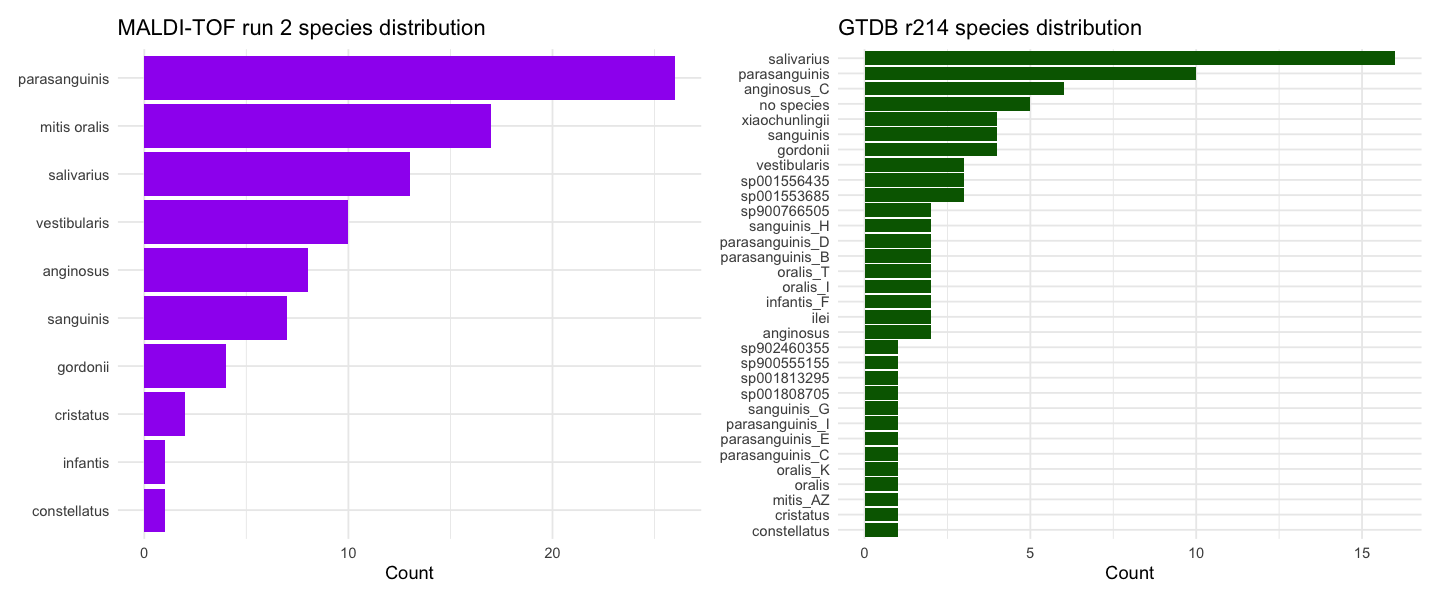

In [11]:
# df from r214 names + df_filtered
df_filtered <- df_filtered |>
  select(-matches("^species_214")) |>
  left_join(
    gtdb_214_qc |>
      distinct(user_genome, .keep_all = TRUE) |>
      select(user_genome, species_214),
    by = c("GM_FILE_ID" = "user_genome")
  )

# df with Resistance info, Maldi and GTDB r214 species identification
species_df <- df_filtered |>
  select(
    SAMPLE_ID,
    Resistance,
    Maldi_2 = `Maldi species 2. test`,
    GTDB_214 = species_214
  ) |>
  mutate(
    Maldi_2 = str_to_lower(str_trim(Maldi_2))
  )

# species distribution
p_gtdb <- species_df |>
  count(GTDB_214, sort = TRUE) |>
  ggplot(aes(x = reorder(GTDB_214, n), y = n)) +
  geom_col(fill = "dark green") +
  coord_flip() +
  labs(title = "GTDB r214 species distribution", x = NULL, y = "Count") +
  theme_minimal()

p_maldi <- species_df |>
  count(Maldi_2, sort = TRUE) |>
  ggplot(aes(x = reorder(Maldi_2, n), y = n)) +
  geom_col(fill = "purple") +
  coord_flip() +
  labs(title = "MALDI-TOF run 2 species distribution", x = NULL, y = "Count") +
  theme_minimal()

options(repr.plot.width = 12, repr.plot.height = 5)
p_maldi | p_gtdb

match_status,n
<chr>,<int>
match,36
mismatch,48
unknown,5


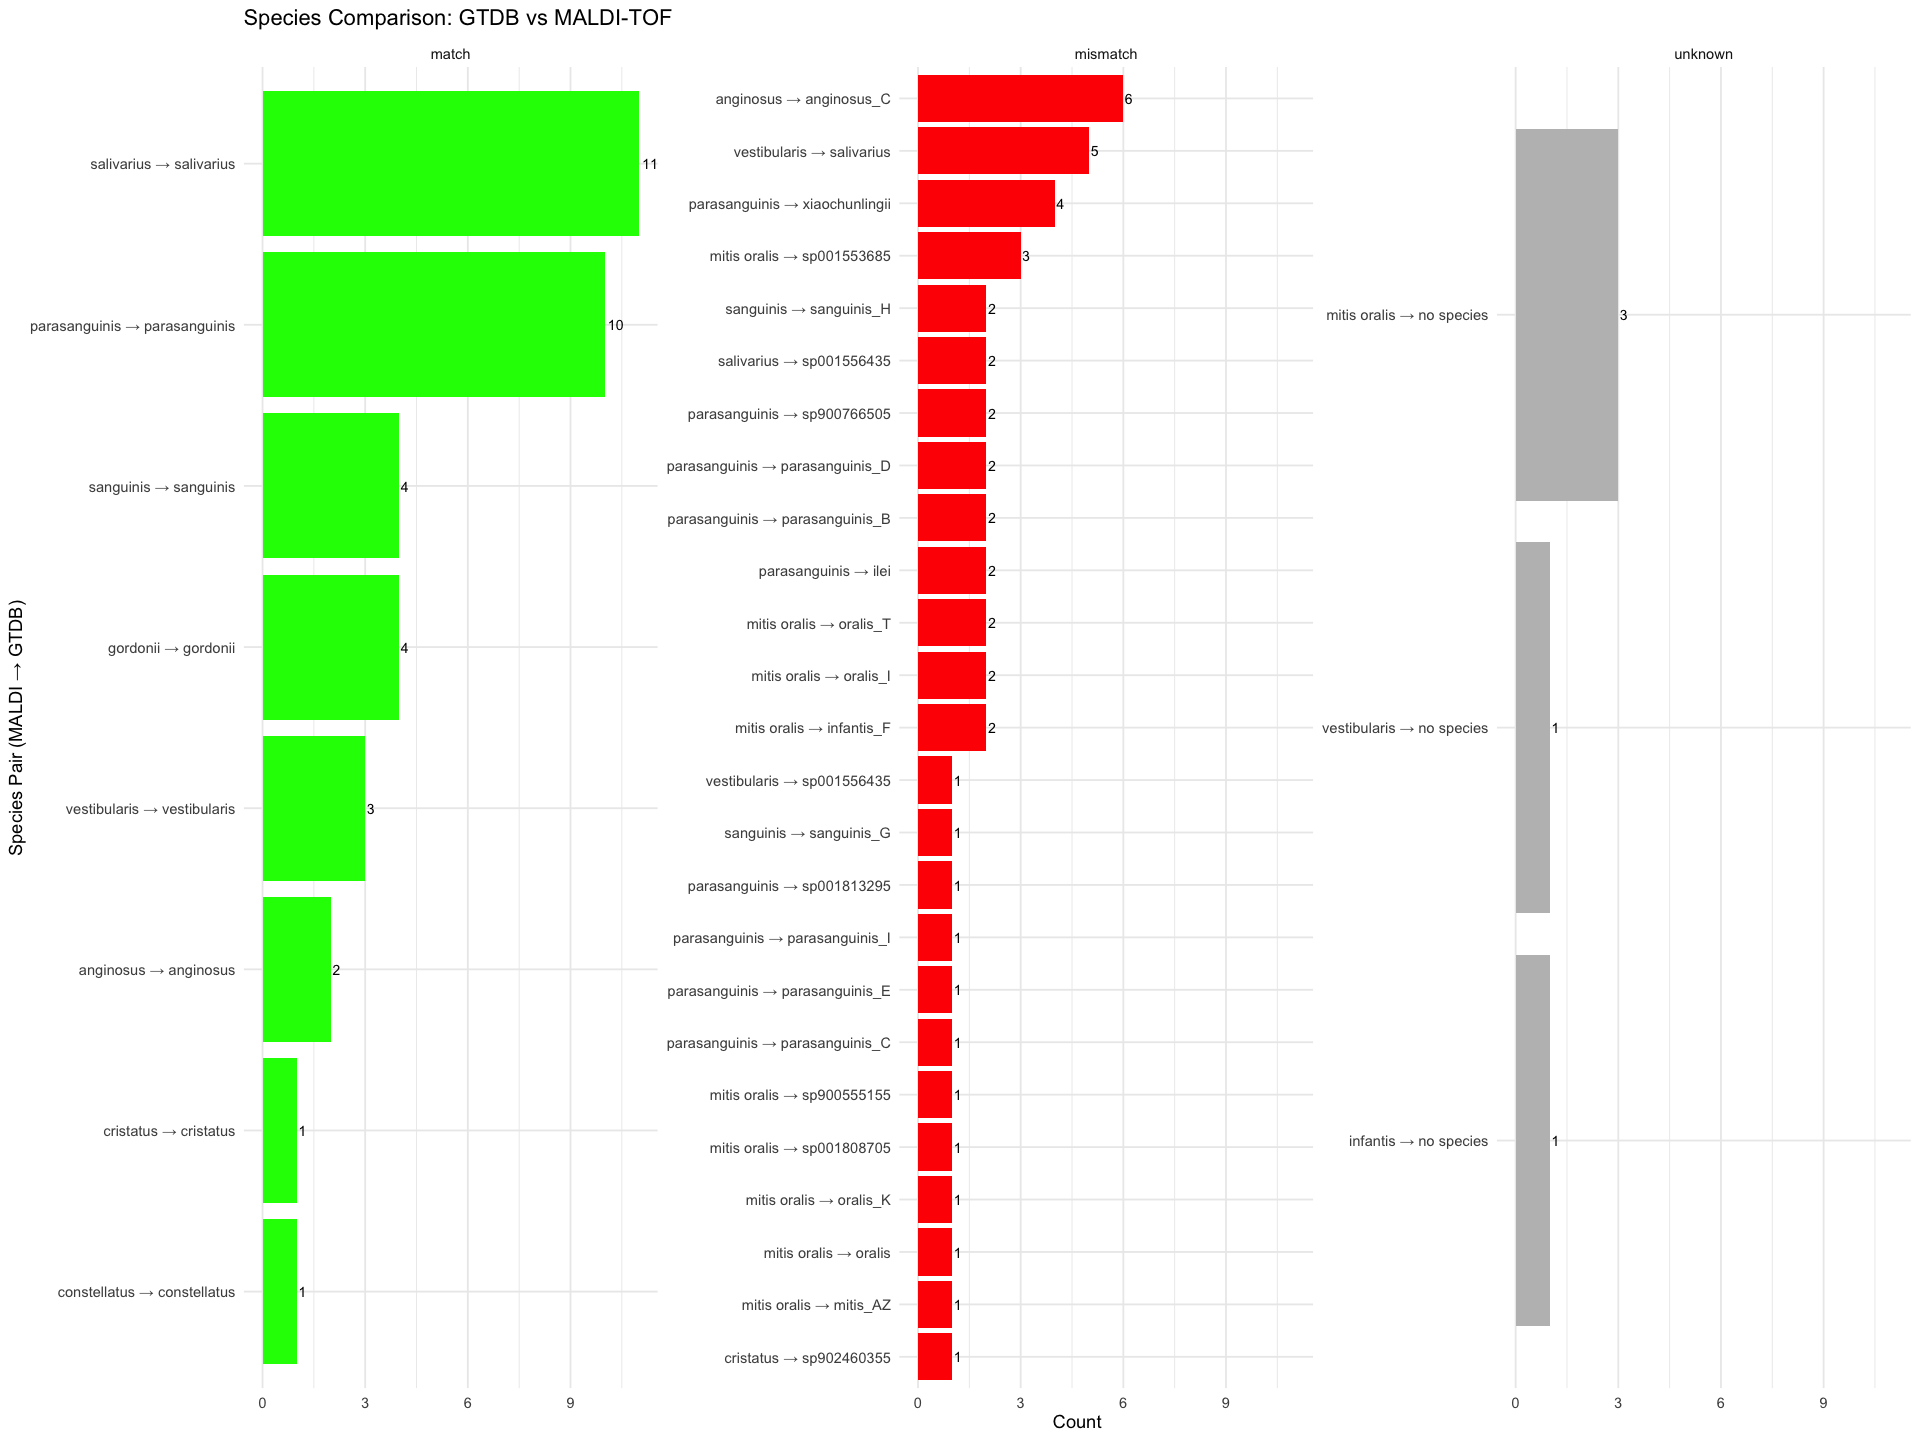

Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”
Warning message in to_lodes_form(data = data, axes = axis_ind, discern = params$discern):
“Some strata appear at multiple axes.”


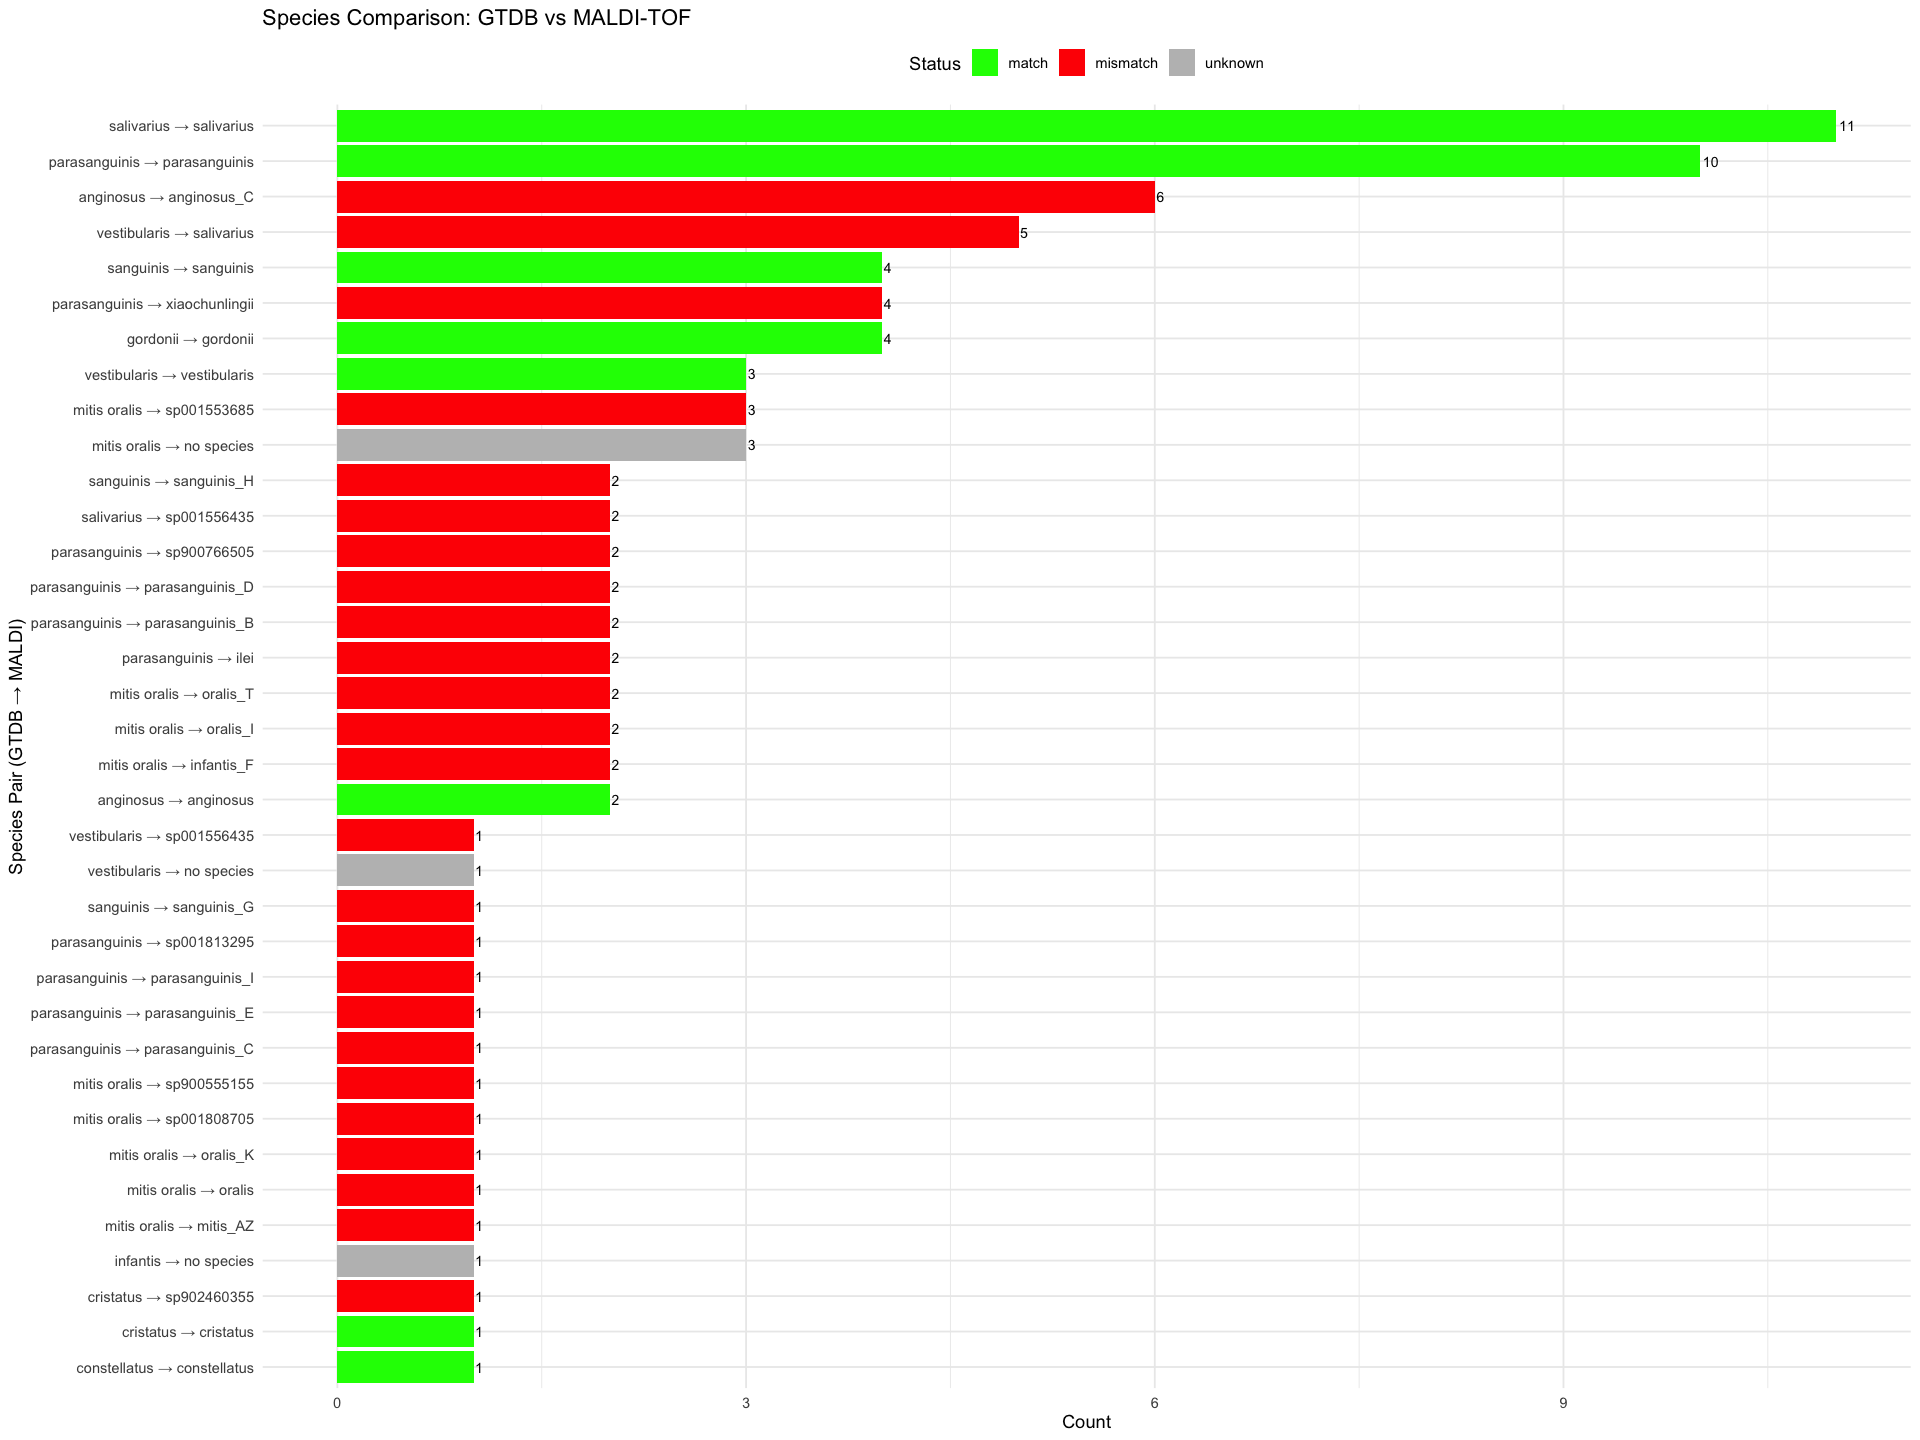

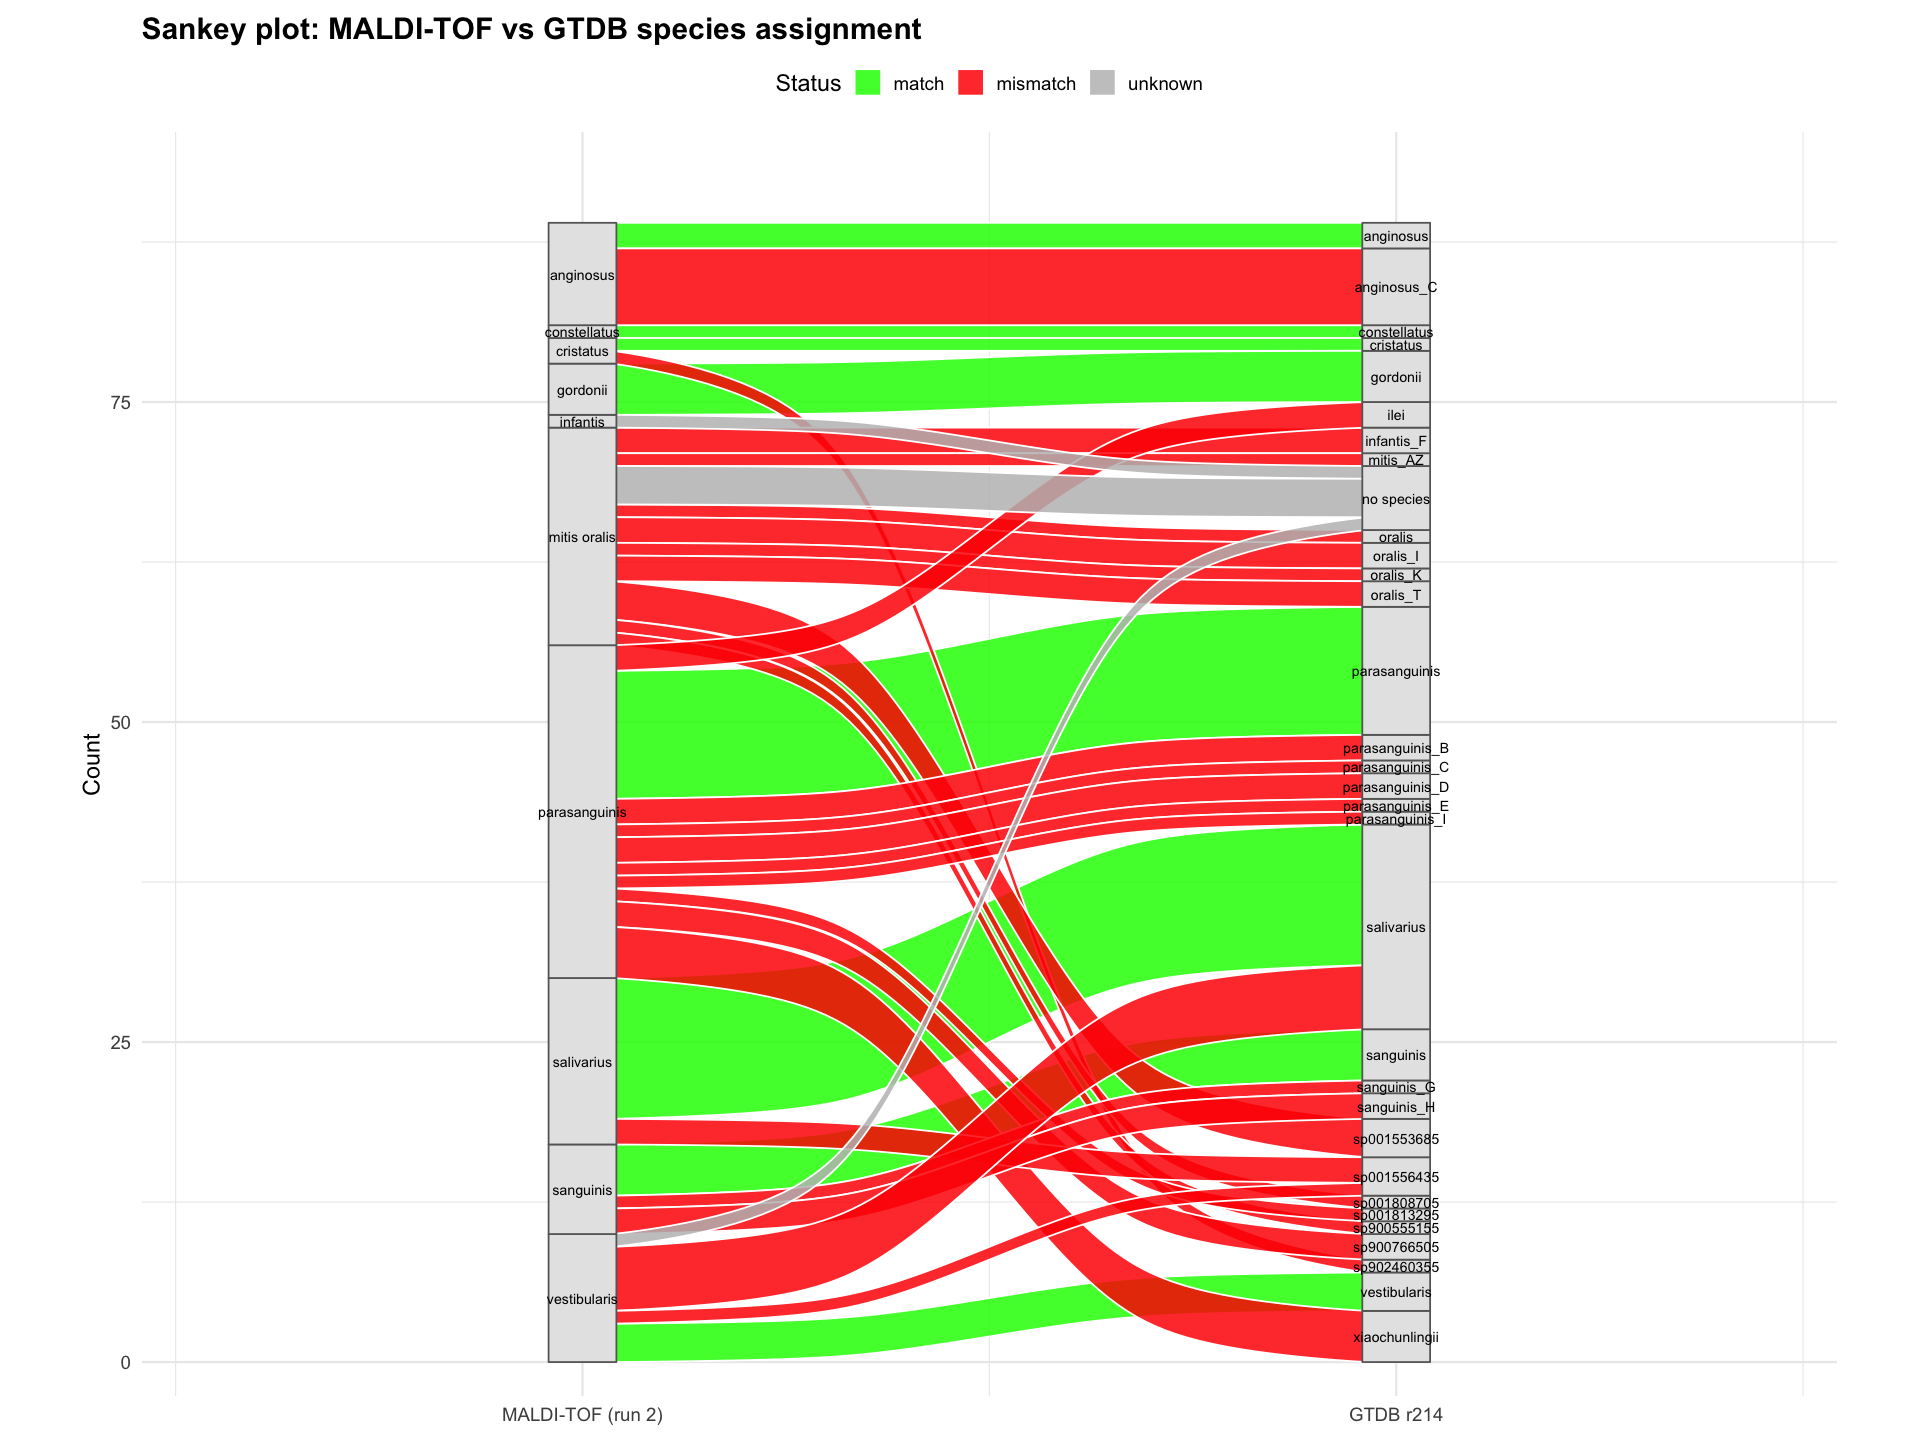

In [19]:
# Match status classification 

species_df <- species_df |>
  mutate(
    match_status = case_when(
      GTDB_214 == "no species" ~ "unknown",
      GTDB_214 == Maldi_2     ~ "match",
      TRUE                    ~ "mismatch"
    )
  )

species_df |> count(match_status)

# Count pairs by status 

combined_counts <- species_df |>
  count(GTDB_214, Maldi_2, status = match_status, sort = TRUE) |>
  mutate(pair = paste(Maldi_2, "→", GTDB_214))

status_colours <- c(match = "green", mismatch = "red", unknown = "gray")

# Bar plots

suppressWarnings({

  # Faceted by status
  print(
    ggplot(combined_counts, aes(x = reorder(pair, n), y = n, fill = status)) +
      geom_col() +
      geom_text(aes(label = n), hjust = -0.2, size = 3) +
      coord_flip() +
      facet_wrap(~status, scales = "free_y", nrow = 1) +
      scale_fill_manual(values = status_colours) +
      labs(
        title = "Species Comparison: GTDB vs MALDI-TOF",
        x     = "Species Pair (MALDI → GTDB)",
        y     = "Count"
      ) +
      theme_minimal() +
      theme(legend.position = "none")
  )

  # All statuses combined
  print(
    ggplot(combined_counts, aes(x = reorder(pair, n), y = n, fill = status)) +
      geom_col() +
      geom_text(aes(label = n), hjust = -0.2, size = 3) +
      coord_flip() +
      scale_fill_manual(values = status_colours) +
      labs(
        title = "Species Comparison: GTDB vs MALDI-TOF",
        x     = "Species Pair (GTDB → MALDI)",
        y     = "Count",
        fill  = "Status"
      ) +
      theme_minimal() +
      theme(legend.position = "top")
  )

})



options(repr.plot.width = 16, repr.plot.height = 12)
theme_set(theme_minimal(base_size = 16))

sankey_df <- species_df |>
  count(Maldi_2, GTDB_214, match_status, name = "n") |>
  filter(!is.na(Maldi_2), !is.na(GTDB_214))

maldi_levels <- sankey_df |> distinct(Maldi_2)  |> arrange(Maldi_2)  |> pull(Maldi_2)
gtdb_levels  <- sankey_df |> distinct(GTDB_214) |> arrange(GTDB_214) |> pull(GTDB_214)

sankey_df <- sankey_df |>
  mutate(
    Maldi_2      = factor(Maldi_2,  levels = maldi_levels),
    GTDB_214     = factor(GTDB_214, levels = gtdb_levels),
    Maldi_2_num  = as.numeric(Maldi_2),
    GTDB_214_num = as.numeric(GTDB_214)
  )

maldi_lookup <- setNames(as.character(maldi_levels), seq_along(maldi_levels))
gtdb_lookup  <- setNames(as.character(gtdb_levels),  seq_along(gtdb_levels))

suppressWarnings(
  ggplot(sankey_df, aes(axis1 = Maldi_2_num, axis2 = GTDB_214_num, y = n)) +
    geom_alluvium(
      aes(fill = match_status),
      width     = 1/14,
      alpha     = 0.85,
      knot.pos  = 0.35,
      colour    = "white",
      linewidth = 0.5
    ) +
    geom_stratum(width = 1/12, fill = "grey90", color = "grey40") +
    geom_text(
      stat = "stratum",
      aes(label = after_stat(ifelse(x == 1, maldi_lookup[stratum], gtdb_lookup[stratum]))),
      size = 3
    ) +
    scale_x_continuous(
      breaks = c(1, 2),
      labels = c("MALDI-TOF (run 2)", "GTDB r214"),
      expand = c(0.24, 0.24)
    ) +
    scale_y_continuous(expand = expansion(mult = c(0.03, 0.08))) +
    scale_fill_manual(values = status_colours) +
    labs(
      title = "Sankey plot: MALDI-TOF vs GTDB species assignment",
      y     = "Count",
      fill  = "Status"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.title.x   = element_blank(),
      legend.position = "top",
      plot.title     = element_text(size = 18, face = "bold"),
      plot.margin    = margin(10, 50, 10, 50)
    )
)

### Antibiotic resistance



NOTE: Quality control filtering was applied above with Genome_sequencing_qc == Pass and Exclude == KEEP.
ResFinder and AMRFinder were both run on all 96 assemblies, but in the analysis below the results are filtered to the 89 kept samples by joining on GM_FILE_ID and automatically dropping excluded samples from further analysis.

AMRFinder 4.2.7     
2 versions of ResFinder were run. The following analysis uses the results from ResFinder version 4.7.2

#### Load and prepare AMR data

In [ ]:
pheno <- read_tsv("../results/amr/combined_pheno_def.tsv", show_col_types = FALSE)
res   <- read_tsv("../results/amr/combined_resfinder_default.tsv", show_col_types = FALSE)

# AMRFinder has a stray "combined\t" prefix on each line — strip it before reading
raw_lines   <- read_lines("../results/amr/combined_amrfinder_def.tsv")
fixed_lines <- str_replace(raw_lines, "^combined\t", "")
write_lines(fixed_lines, "../results/amr/combined_amrfinder_def.tsv")

amr <- read_tsv("../results/amr/combined_amrfinder_def.tsv", show_col_types = FALSE) |>
    rename_with(~ str_replace_all(., " ", "_") |> str_to_lower())

cat("pheno rows:", nrow(pheno), "\n")
cat("res rows:  ", nrow(res),   "\n")
cat("amr rows:  ", nrow(amr), "  columns:", ncol(amr), "\n")
cat("distinct samples — amr:", n_distinct(amr$sample),
                        " res:", n_distinct(res$Sample), "\n")

pheno rows: 8736 
res rows:   249 
amr rows:   241   columns: 23 
distinct samples — amr: 80  res: 80 


#### Filter to QC passed

In [21]:
valid_ids <- df_filtered |> pull(GM_FILE_ID)

pheno_clean <- pheno |> filter(Sample %in% valid_ids)
res_clean   <- res   |> filter(Sample %in% valid_ids)
amr_clean   <- amr   |> filter(sample %in% valid_ids)

cat("Samples retained — pheno:", n_distinct(pheno_clean$Sample),
    " ResFinder:", n_distinct(res_clean$Sample),
    " AMRFinder:", n_distinct(amr_clean$sample), "\n")

Samples retained — pheno: 89  ResFinder: 76  AMRFinder: 76 


#### Resistance overview

In [22]:
# count of isolates per resistance category
df_filtered |> group_by(Resistance) |> count()

# quick look at resistant pheno entries and gene counts
print(pheno_clean |> filter(WGS_phenotype != "No resistance") |> head())
res_clean |> group_by(`Resistance gene`) |> count()

# export phenotypically resistant isolates joined with disk diffusion data
pheno_clean |>
    filter(WGS_phenotype != "No resistance") |>
    left_join(
        df_filtered |> select(GM_FILE_ID, `Zone diameter`, Resistance),
        by = c("Sample" = "GM_FILE_ID")
    ) |>
    write_tsv("../results/amr/antimicrobial_resistance_output.tsv")

Resistance,n
<chr>,<int>
Ampicillin_resistant,19
Clindamycin_resistant,45
Penicillin_resistant,10
NA,15


# A tibble: 6 × 6
  Sample              Antimicrobial Class WGS_phenotype Match Genetic_background
  <chr>               <chr>         <chr> <chr>         <dbl> <chr>             
1 0043m-CMPN001x78_2… erythromycin  macr… Resistant         3 msr(D) (msr(D)_AF…
2 0043m-CMPN001x78_2… azithromycin  macr… Resistant         3 msr(D) (msr(D)_AF…
3 0043m-CMPN001x78_2… telithromycin macr… Resistant         3 msr(D) (msr(D)_AF…
4 0043m-CMPN001x78_2… quinupristin  stre… Resistant         3 msr(D) (msr(D)_AF…
5 0043m-CMPN001x78_2… pristinamyci… stre… Resistant         3 msr(D) (msr(D)_AF…
6 0043m-CMPN001x78_2… virginiamyci… stre… Resistant         3 msr(D) (msr(D)_AF…


Resistance gene,n
<chr>,<int>
cat(pC194),1
erm(B),55
lsa(C),6
mef(A),35
msr(D),35
tet(32),1
tet(M),53
tet(O),2
tet(W),1


#### Top AMR genes per antibiotic class

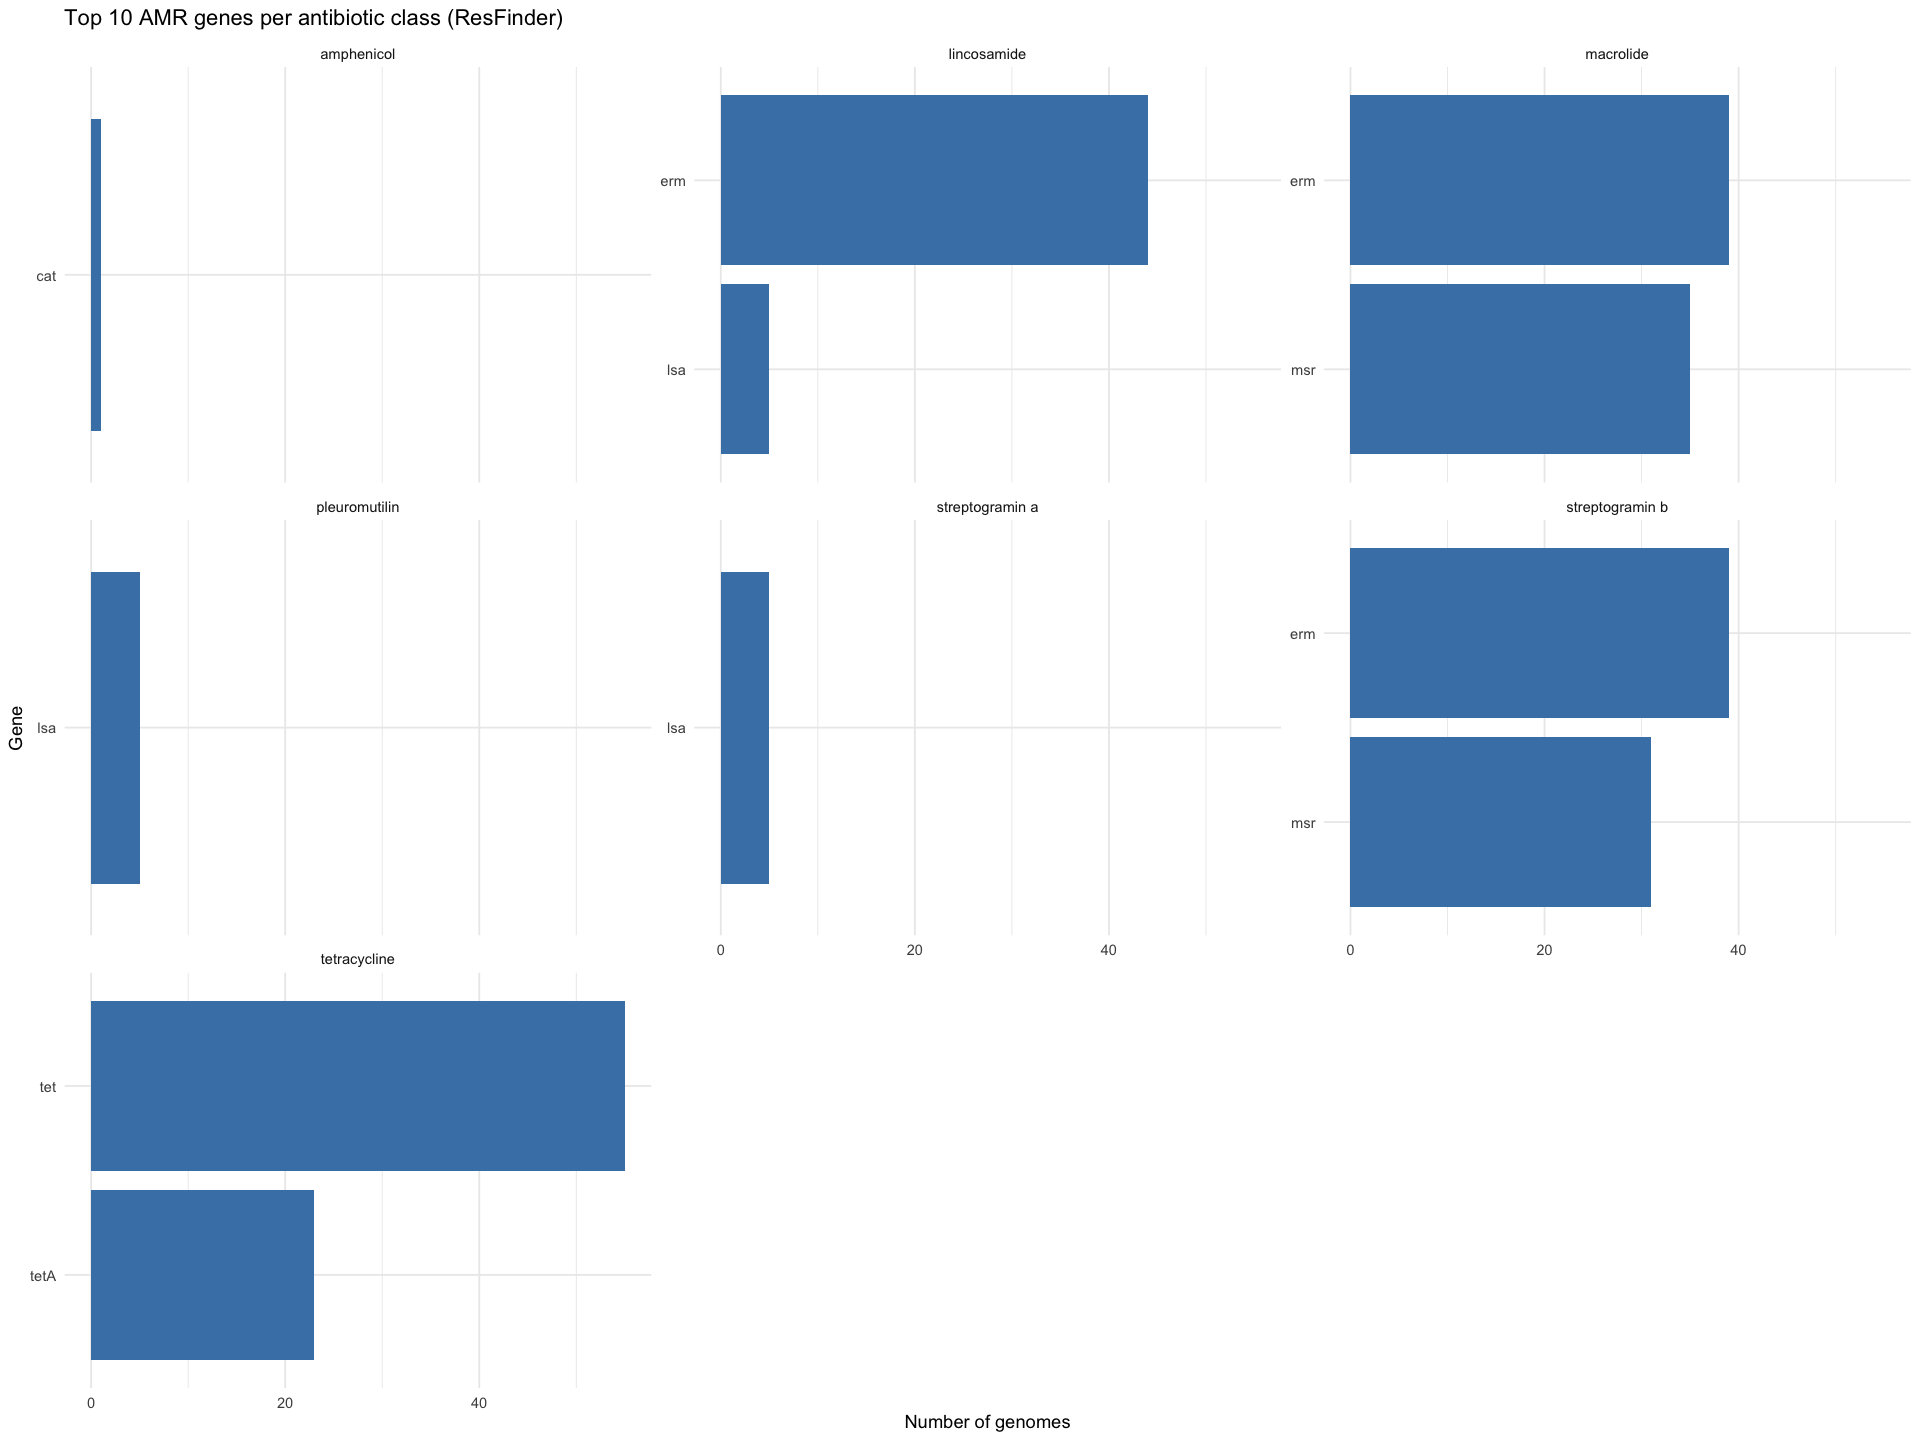

In [24]:
pheno_resistant <- pheno_clean |> filter(WGS_phenotype != "No resistance")

top_genes_separate <- pheno_resistant |>
    filter(!is.na(Genetic_background), Genetic_background != "") |>
    separate_rows(Genetic_background, sep = ",") |>
    mutate(gene = str_extract(Genetic_background, "^[^\\s(]+") |> str_trim()) |>
    filter(!is.na(gene), gene != "") |>
    distinct(Sample, Class, gene) |>
    count(gene, Class, name = "n") |>
    group_by(Class) |>
    slice_max(n, n = 10) |>
    ungroup()

ggplot(top_genes_separate, aes(x = reorder(gene, n), y = n)) +
    geom_col(fill = "steelblue") +
    coord_flip() +
    facet_wrap(~Class, scales = "free_y") +
    labs(
        title = "Top 10 AMR genes per antibiotic class (ResFinder)",
        x     = "Gene",
        y     = "Number of genomes"
    ) +
    theme_minimal()

#### Close up on beta-lactam resistance

SAMPLE_ID,GM_FILE_ID,Number_contigs_genome,Genome_size,Species_GTDB_release207_ANIpercent,Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc,Resistance,Maldi species 2. test,Zone diameter,species_214
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
146Pp,146Pp-CMPN001x69_260114_LH00793_B23GCKKLT3,22,2005923,Streptococcus xiaochunlingii (96.4%),"mef(A)_2,msr(D)_2,tet(M)_4,tetA(46)_1,tetB(46)_1",Penicillin_resistant,Parasanguinis,R0,xiaochunlingii


SAMPLE_ID,GM_FILE_ID,Number_contigs_genome,Genome_size,Species_GTDB_release207_ANIpercent,Abricate_resfinder-v2019-09-10_genes_coverage_lt_60perc_identity_lt_90perc,Resistance,Maldi species 2. test,Zone diameter,species_214
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
111Ap,111Ap-CMPN001x58_260114_LH00793_B23GCKKLT3,62,2137179,Streptococcus parasanguinis (96.9%),"mef(A)_2,msr(D)_2,tetA(46)_1,tetB(46)_1",Ampicillin_resistant,Parasanguinis,R0,parasanguinis
113Ap,113Ap-CMPN001x59_260114_LH00793_B23GCKKLT3,39,2158545,Streptococcus parasanguinisxB (95.6%),"mef(A)_2,msr(D)_2,tetA(46)_1,tetB(46)_1",Ampicillin_resistant,Parasanguinis,R0,parasanguinis_B
124Ap,124Ap-CMPN001x61_260114_LH00793_B23GCKKLT3,109,2151668,Streptococcus parasanguinis (96.7%),"mef(A)_2,msr(D)_2,tetA(46)_1,tetB(46)_1",Ampicillin_resistant,Parasanguinis,R0,parasanguinis


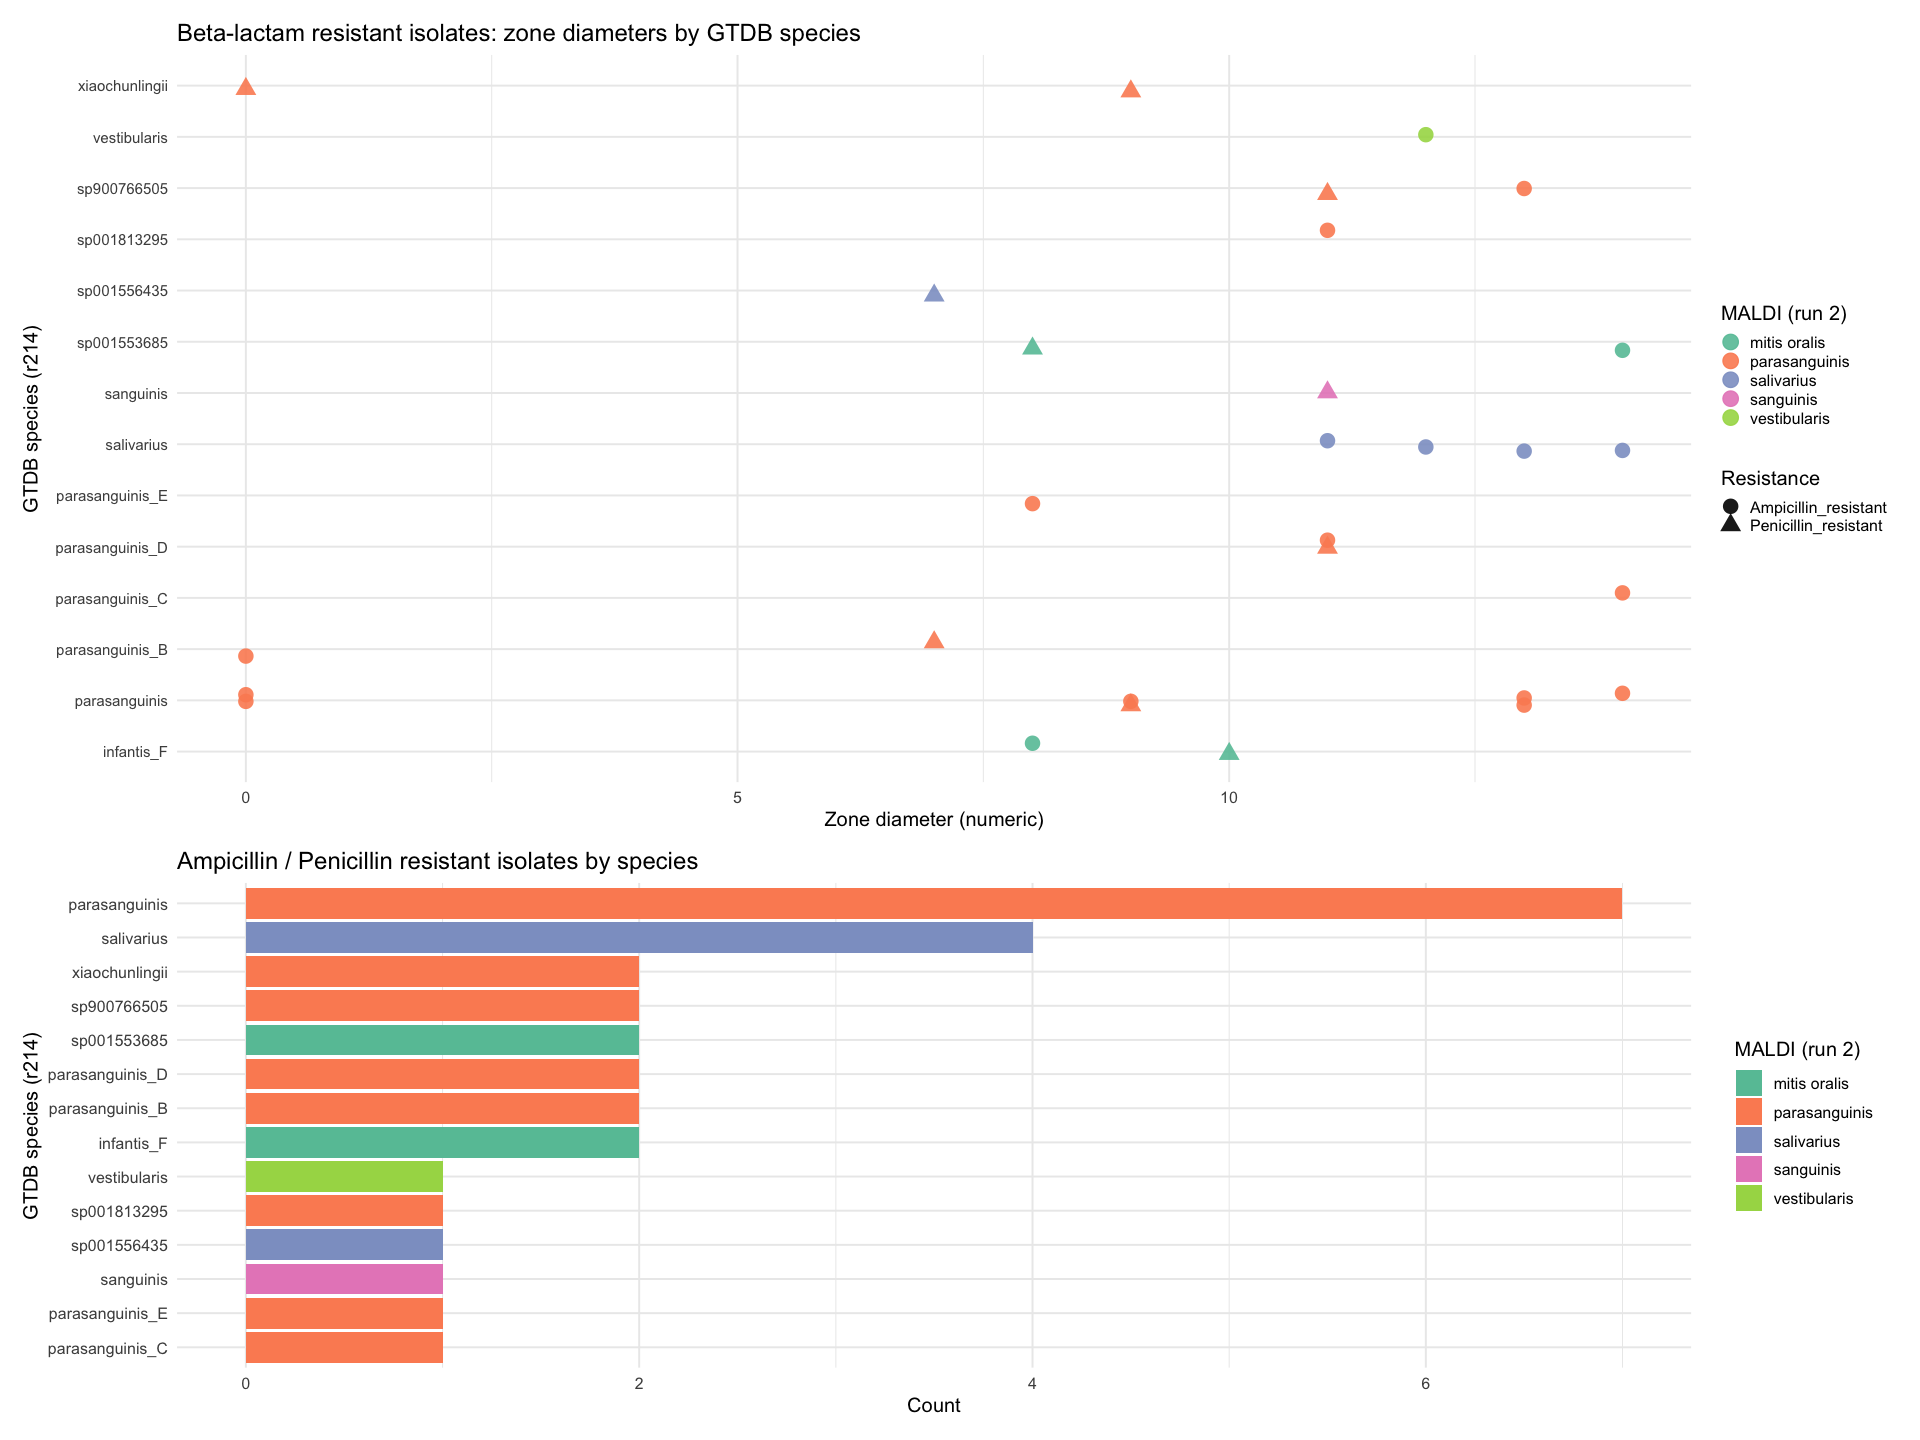

In [25]:
betalactam_resistant <- df_filtered |>
  filter(Resistance %in% c("Ampicillin_resistant", "Penicillin_resistant")) |>
  select(SAMPLE_ID, Resistance, `Maldi species 2. test`, species_214, `Zone diameter`)

betalactam_resistant2 <- betalactam_resistant |>
  transmute(
    SAMPLE_ID  = as.character(SAMPLE_ID),
    Resistance = factor(Resistance, levels = c("Ampicillin_resistant", "Penicillin_resistant")),
    Maldi      = str_to_lower(str_trim(`Maldi species 2. test`)),
    GTDB       = str_trim(species_214),
    zone_num   = parse_number(str_replace_all(as.character(`Zone diameter`), "[Rr]", ""))
  )

# build colour palette scaled to however many MALDI labels are in this subset
maldi_levels <- betalactam_resistant2 |>
  pull(Maldi) |> unique() |> na.omit() |> as.character() |> sort()

n_maldi <- length(maldi_levels)
maldi_palette <- if (n_maldi == 0) {
  character(0)
} else if (n_maldi <= 8) {
  setNames(RColorBrewer::brewer.pal(max(3, n_maldi), "Set2")[1:n_maldi], maldi_levels)
} else {
  setNames(colorRampPalette(RColorBrewer::brewer.pal(8, "Set2"))(n_maldi), maldi_levels)
}

betalactam_resistant2 <- betalactam_resistant2 |>
  mutate(Maldi = factor(Maldi, levels = maldi_levels))

p_zone <- betalactam_resistant2 |>
  ggplot(aes(x = GTDB, y = zone_num, colour = Maldi, shape = Resistance)) +
  geom_jitter(width = 0.18, height = 0, size = 4, alpha = 0.9, na.rm = TRUE) +
  coord_flip() +
  scale_colour_manual("MALDI (run 2)", values = maldi_palette, na.value = "grey60") +
  scale_shape_manual("Resistance", values = c(Ampicillin_resistant = 16, Penicillin_resistant = 17)) +
  labs(
    title = "Beta-lactam resistant isolates: zone diameters by GTDB species",
    x     = "GTDB species (r214)",
    y     = "Zone diameter (numeric)"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    axis.text.y      = element_text(size = 9),
    legend.position  = "right",
    legend.key.size  = grid::unit(0.6, "lines")
  )

p_counts <- betalactam_resistant2 |>
  count(GTDB, Maldi) |>
  ggplot(aes(x = reorder(GTDB, n), y = n, fill = Maldi)) +
  geom_col() +
  coord_flip() +
  scale_fill_manual("MALDI (run 2)", values = maldi_palette, na.value = "grey60") +
  labs(
    title = "Ampicillin / Penicillin resistant isolates by species",
    x     = "GTDB species (r214)",
    y     = "Count"
  ) +
  theme_minimal(base_size = 12)

(p_zone / p_counts) + plot_layout(heights = c(1.5, 1))

# isolates with zone diameter coded as fully resistant (R0)
df_filtered |> filter(Resistance == "Penicillin_resistant", `Zone diameter` == "R0")
df_filtered |> filter(Resistance == "Ampicillin_resistant", `Zone diameter` == "R0")

#### Susceptibility vs resistance gene presence

In [31]:
susceptible_ids <- df_filtered |> filter(is.na(Resistance))  |> pull(GM_FILE_ID)
pheno_res_ids   <- df_filtered |> filter(!is.na(Resistance)) |> pull(GM_FILE_ID)
cat("Phenotypically resistant:", length(pheno_res_ids),
    " Susceptible:", length(susceptible_ids), "\n")

# susceptible isolates that still carry resistance genes in AMRFinder
sus_with_amr <- amr_clean |>
  filter(sample %in% susceptible_ids) |>
  select(sample, element_symbol, element_name)

print(sus_with_amr)
cat("Susceptible isolates with AMR genes:", n_distinct(sus_with_amr$sample), "out of", length(susceptible_ids), "\n")

# resistant isolates absent from AMRFinder output
amr_ids      <- amr_clean |> distinct(sample) |> pull(sample)
missing_in_amr <- setdiff(pheno_res_ids, amr_ids)
cat("Resistant isolates missing from AMRFinder:", length(missing_in_amr), "\n")
print(missing_in_amr)

# breakdown of susceptible-with-AMR-genes by species
#  which species tend to carry silent resistance genes
sus_with_amr |>
  distinct(sample) |>
  left_join(df_filtered |> select(GM_FILE_ID, species_214), by = c("sample" = "GM_FILE_ID")) |>
  count(species_214, sort = TRUE) |>
  print()

# count genes
sus_with_amr |>
  left_join(df_filtered |> select(GM_FILE_ID, species_214), by = c("sample" = "GM_FILE_ID")) |>
  count(species_214, element_symbol, sort = TRUE) |> print()


Phenotypically resistant: 74  Susceptible: 15 
# A tibble: 16 × 3
   sample                                     element_symbol element_name       
   <chr>                                      <chr>          <chr>              
 1 0043m-CMPN001x78_260114_LH00793_B23GCKKLT3 msr(D)         ABC-F type ribosom…
 2 0043m-CMPN001x78_260114_LH00793_B23GCKKLT3 mef(A)         macrolide efflux M…
 3 0048m-CMPN001x79_260114_LH00793_B23GCKKLT3 mef(A)         macrolide efflux M…
 4 0048m-CMPN001x79_260114_LH00793_B23GCKKLT3 msr(D)         ABC-F type ribosom…
 5 0068m-CMPN001x83_260114_LH00793_B23GCKKLT3 tet(M)         tetracycline resis…
 6 0068m-CMPN001x83_260114_LH00793_B23GCKKLT3 msr(D)         ABC-F type ribosom…
 7 0068m-CMPN001x83_260114_LH00793_B23GCKKLT3 mef(A)         macrolide efflux M…
 8 0076m-CMPN001x85_260114_LH00793_B23GCKKLT3 msr(D)         ABC-F type ribosom…
 9 0076m-CMPN001x85_260114_LH00793_B23GCKKLT3 mef(A)         macrolide efflux M…
10 0116p-CMPN001x93_260114_LH00793_B23GCKKL

#### MDR & gene clustering

# A tibble: 4 × 4
  mdr_category         n percent percent_label
  <chr>            <int>   <dbl> <chr>        
1 MDR (≥3 classes)    65   73.0  73.0%        
2 Susceptible         13   14.6  14.6%        
3 Two classes          6    6.74 6.7%         
4 Single class         5    5.62 5.6%         


cluster,n_genes,genes
<int>,<int>,<chr>
1,2,"erm(B), tet(M)"
2,4,"mef(A), msr(D), tetA(46), tetB(46)"
3,1,tet(O)
4,1,lsa(C)


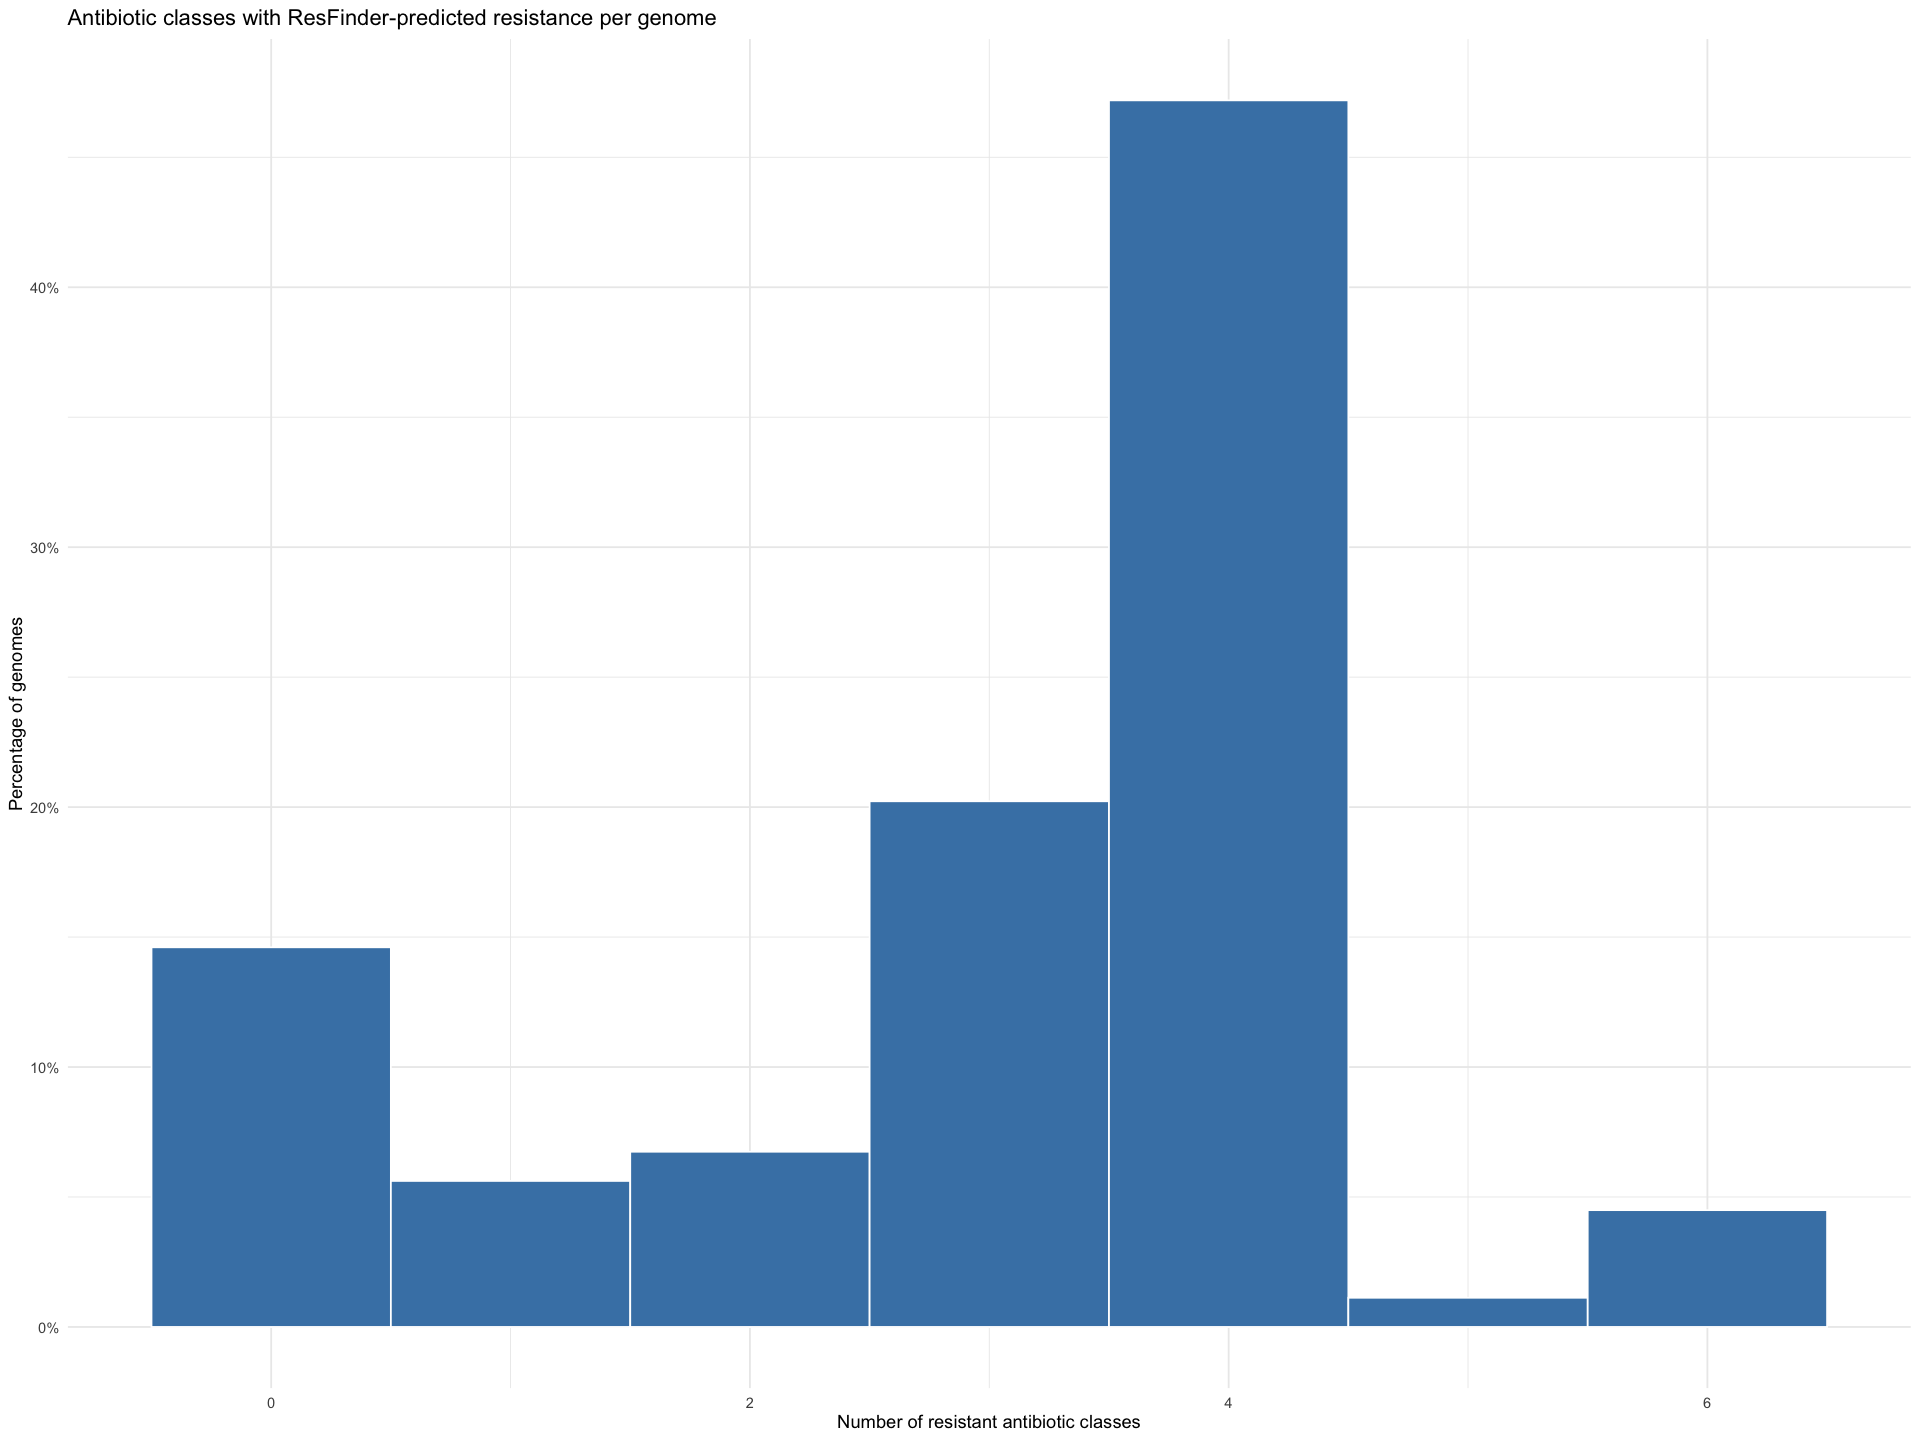

In [35]:
# classify each sample by number of resistant antibiotic classes
mdr <- pheno_clean |>
  filter(WGS_phenotype == "Resistant") |>
  distinct(Sample, Class) |>
  count(Sample, name = "n_resistant_classes") |>
  mutate(mdr_category = case_when(
    n_resistant_classes == 1 ~ "Single class",
    n_resistant_classes == 2 ~ "Two classes",
    n_resistant_classes >= 3 ~ "MDR (≥3 classes)"
  ))

# add susceptible samples so all valid IDs are represented
no_res   <- tibble(Sample = setdiff(valid_ids, mdr$Sample),
                   n_resistant_classes = 0,
                   mdr_category = "Susceptible")
mdr_full <- bind_rows(mdr, no_res)

# summary table with percentages
mdr_summary <- mdr_full |>
  count(mdr_category) |>
  mutate(
    percent       = 100 * n / sum(n),
    percent_label = sprintf("%.1f%%", percent)
  ) |>
  arrange(desc(n))

print(mdr_summary)

mdr_full |>
  ggplot(aes(x = n_resistant_classes, y = after_stat(count / sum(count)))) +
  geom_histogram(binwidth = 1, fill = "steelblue", color = "white") +
  scale_y_continuous(labels = scales::percent_format(accuracy = 1)) +
  labs(
    title = "Antibiotic classes with ResFinder-predicted resistance per genome",
    x     = "Number of resistant antibiotic classes",
    y     = "Percentage of genomes"
  ) +
  theme_minimal()

# gene co-occurrence among MDR isolates (≥3 resistant classes)
mdr_samples <- mdr_full |>
  filter(mdr_category == "MDR (≥3 classes)") |>
  pull(Sample) |>
  as.character()

mdr_genes <- amr_clean |>
  filter(sample %in% mdr_samples, !is.na(element_symbol), element_symbol != "") |>
  transmute(
    sample_id = as.character(sample),
    gene      = str_trim(element_symbol)
  ) |>
  distinct(sample_id, gene)

gene_mat <- mdr_genes |>
  mutate(present = 1L) |>
  pivot_wider(names_from = gene, values_from = present, values_fill = 0L) |>
  column_to_rownames("sample_id") |>
  as.matrix()

# keep genes seen in at least 2 MDR isolates
gene_mat <- gene_mat[, colSums(gene_mat) >= 2, drop = FALSE]

# cluster by Jaccard-like co-occurrence distance
gene_dist   <- dist(t(gene_mat), method = "binary")
gene_hc     <- hclust(gene_dist, method = "average")
gene_groups <- cutree(gene_hc, k = 4)

gene_group_table <- tibble(
  gene    = names(gene_groups),
  cluster = gene_groups
) |>
  arrange(cluster, gene)

gene_group_summary <- gene_group_table |>
  group_by(cluster) |>
  summarise(
    n_genes = n(),
    genes   = paste(gene, collapse = ", "),
    .groups = "drop"
  )

gene_group_summary

#### ResFinder and AMRFinder concordance

sample,element_symbol
<chr>,<chr>
033Cm-CMPN001x01_260114_LH00793_B23GCKKLT3,catA
094Cm-CMPN001x16_260114_LH00793_B23GCKKLT3,lsa


sample,element_symbol
<chr>,<chr>
033Cm-CMPN001x01_260114_LH00793_B23GCKKLT3,cat(pC194)


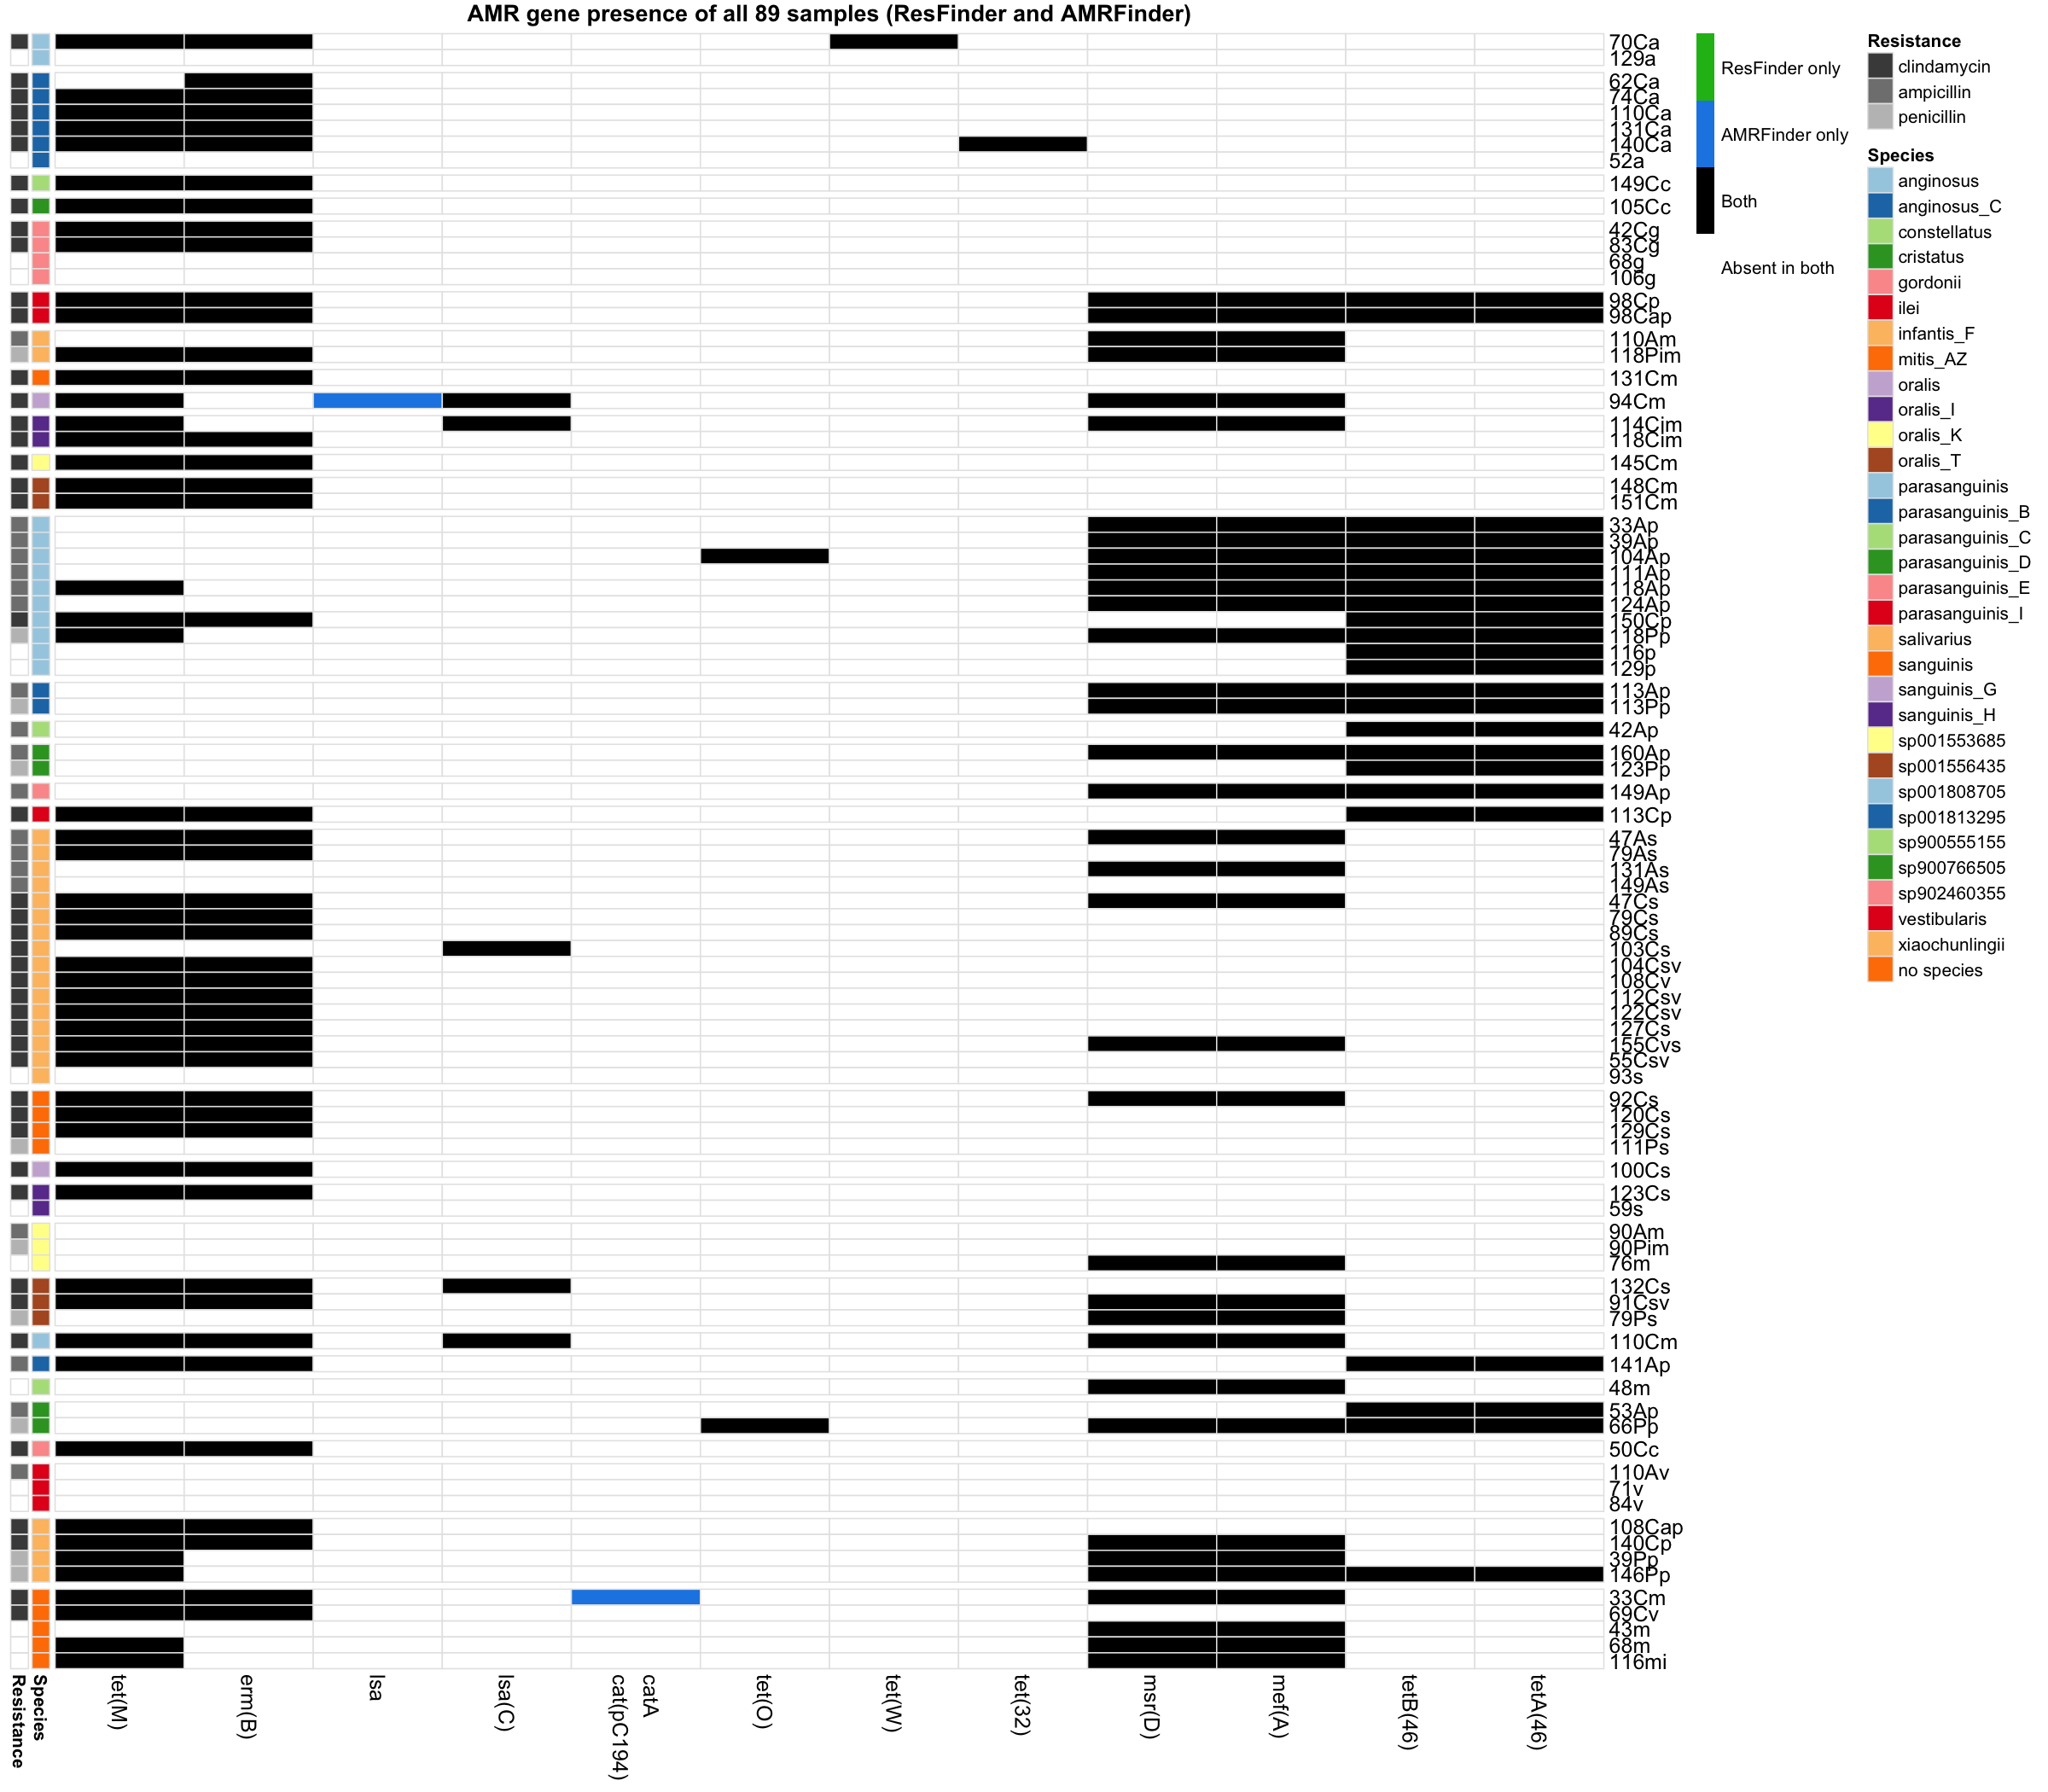

In [38]:
options(repr.plot.width = 16, repr.plot.height = 14, repr.plot.res = 150)

# sample annotation: species and resistance
annot <- species_df |>
  select(SAMPLE_ID, GTDB_214) |>
  left_join(df_filtered |> select(SAMPLE_ID, Resistance), by = "SAMPLE_ID") |>
  rename(Species = GTDB_214) |>
  distinct(SAMPLE_ID, .keep_all = TRUE)

all_sample_ids <- annot$SAMPLE_ID

# AMRFinder presence/absence matrix
pa_mat_amr <- amr_clean |>
  filter(!is.na(element_symbol)) |>
  mutate(sample_short = sub("-.*", "", sample) |> sub("^0+", "", x = _)) |>
  distinct(sample_short, element_symbol) |>
  mutate(present = 1L) |>
  pivot_wider(names_from = element_symbol, values_from = present, values_fill = 0L) |>
  (\(d) tibble(sample_short = all_sample_ids) |>
    left_join(d, by = "sample_short") |>
    mutate(across(-sample_short, ~replace_na(as.integer(.x), 0L))))() |>
  column_to_rownames("sample_short") |>
  as.matrix()

# ResFinder presence/absence matrix, sorted to match AMRFinder row order
pa_mat_res <- res_clean |>
  filter(!is.na(`Resistance gene`)) |>
  mutate(sample_short = sub("-.*", "", Sample) |> sub("^0+", "", x = _)) |>
  distinct(sample_short, `Resistance gene`) |>
  mutate(present = 1L) |>
  pivot_wider(names_from = `Resistance gene`, values_from = present, values_fill = 0L) |>
  (\(d) tibble(sample_short = all_sample_ids) |>
    left_join(d, by = "sample_short") |>
    mutate(across(-sample_short, ~replace_na(as.integer(.x), 0L))))() |>
  column_to_rownames("sample_short") |>
  as.matrix()

# sort rows by species then resistance, "no species" last
annot_sorted_amr <- annot |>
  filter(SAMPLE_ID %in% rownames(pa_mat_amr)) |>
  arrange(Species == "no species", Species, Resistance) |>
  column_to_rownames("SAMPLE_ID")

sorted_order_amr <- rownames(annot_sorted_amr)
pa_mat_amr <- pa_mat_amr[sorted_order_amr, , drop = FALSE]
pa_mat_res <- pa_mat_res[sorted_order_amr, , drop = FALSE]

# gaps between species groups for heatmap rows
gaps <- which(diff(as.numeric(factor(annot_sorted_amr$Species,
                                     levels = unique(annot_sorted_amr$Species)))) != 0)

# clean up resistance labels for annotation
annot_sorted_clean_amr <- annot_sorted_amr |>
  mutate(Resistance = str_remove(Resistance, "_resistant") |> str_to_lower())

# annotation colours
species_names <- unique(annot_sorted_clean_amr$Species)
species_cols  <- setNames(
  rep(RColorBrewer::brewer.pal(12, "Paired"), length.out = length(species_names)),
  species_names
)

ann_colors <- list(
  Species    = species_cols,
  Resistance = c(clindamycin = "#4A4A4A", ampicillin = "#808080", penicillin = "#BFBFBF")
)

# align ResFinder matrix to AMRFinder column order (AMRFinder = reference)
amr_cols <- colnames(pa_mat_amr)

# pad ResFinder with zeros for any genes it didn't detect
missing_in_res <- setdiff(amr_cols, colnames(pa_mat_res))
if (length(missing_in_res) > 0) {
  pa_mat_res <- cbind(
    pa_mat_res,
    matrix(0L,
           nrow     = nrow(pa_mat_res),
           ncol     = length(missing_in_res),
           dimnames = list(rownames(pa_mat_res), missing_in_res))
  )
}
pa_mat_res <- pa_mat_res[rownames(pa_mat_amr), amr_cols, drop = FALSE]

# encode agreement state per cell:
# 0 = absent in both, 1 = both, 2 = AMRFinder only, 3 = ResFinder only
amr_bin   <- (pa_mat_amr > 0) * 1L
res_bin   <- (pa_mat_res > 0) * 1L

state_mat <- ifelse(amr_bin == 1 & res_bin == 1, 1L,
             ifelse(amr_bin == 1 & res_bin == 0, 2L,
             ifelse(amr_bin == 0 & res_bin == 1, 3L, 0L)))
state_mat <- matrix(as.integer(state_mat), nrow = nrow(amr_bin), dimnames = dimnames(amr_bin))

# rename catA column to clarify the ResFinder equivalent
colnames(state_mat) <- ifelse(
  colnames(pa_mat_amr) != "catA",
  colnames(pa_mat_amr),
  "catA\ncat(pC194)"
)

state_cols <- c(
  "0" = "white",
  "1" = "black",
  "2" = "#1E88E5",  # AMRFinder only
  "3" = "#1dba1a"   # ResFinder only
)

pheatmap(
  state_mat,
  annotation_row    = annot_sorted_clean_amr,
  annotation_colors = ann_colors,
  color             = unname(state_cols[c("0", "1", "2", "3")]),
  breaks            = c(-0.5, 0.5, 1.5, 2.5, 3.5),
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps,
  border_color      = "grey90",
  fontsize_row      = 12,
  fontsize_col      = 12,
  angle_col         = 270,
  legend_breaks     = 0:3,
  legend_labels     = c("Absent in both", "Both", "AMRFinder only", "ResFinder only"),
  main              = "AMR gene presence of all 89 samples (ResFinder and AMRFinder)"
)


subset_amr <- amr_clean |> select(sample, element_symbol)

subset_res <- res_clean |>
  select(Sample, `Resistance gene`) |>
  rename(sample = Sample, element_symbol = `Resistance gene`)

# in AMRFinder but not ResFinder
dplyr::setdiff(subset_amr, subset_res)

# in ResFinder but not AMRFinder
dplyr::setdiff(subset_res, subset_amr)


### AllTheBacteria comparison

AllTheBacteria database already contains a file with all results from AMRfinder, available for the last verson of AMRfinder as well. But since it is not specified which thresholds they used, I can assume they used default settings, which is 0.5 coverage and 0.9 identity. That is not the same as in our research, where 0.6 coverage was used. So I decided to rerun the analysis, which also allows me to run them through ResFinder as well.

final dataset:


| Species | Genomes |
|---|---|
| anginosus | 173 |
| anginosus_C | 65 |
| constellatus | 46 |
| cristatus | 25 |
| gordonii | 93 |
| ilei | 6 |
| infantis_F | 16 |
| mitis_AZ | 5 |
| oralis | 106 |
| oralis_I | 6 |
| oralis_K | 1 |
| oralis_T | 13 |
| parasanguinis | 52 |
| parasanguinis_B | 3 |
| parasanguinis_C | 5 |
| parasanguinis_D | 12 |
| parasanguinis_E | 24 |
| parasanguinis_I | 11 |
| salivarius | 179 |
| sanguinis | 48 |
| sanguinis_G | 1 |
| sanguinis_H | 30 |
| sp001553685 | 5 |
| sp001556435 | 55 |
| sp001808705 | 7 |
| sp001813295 | 1 |
| sp900555155 | 1 |
| sp900766505 | 11 |
| vestibularis | 14 |
| xiaochunlingii | 20 |

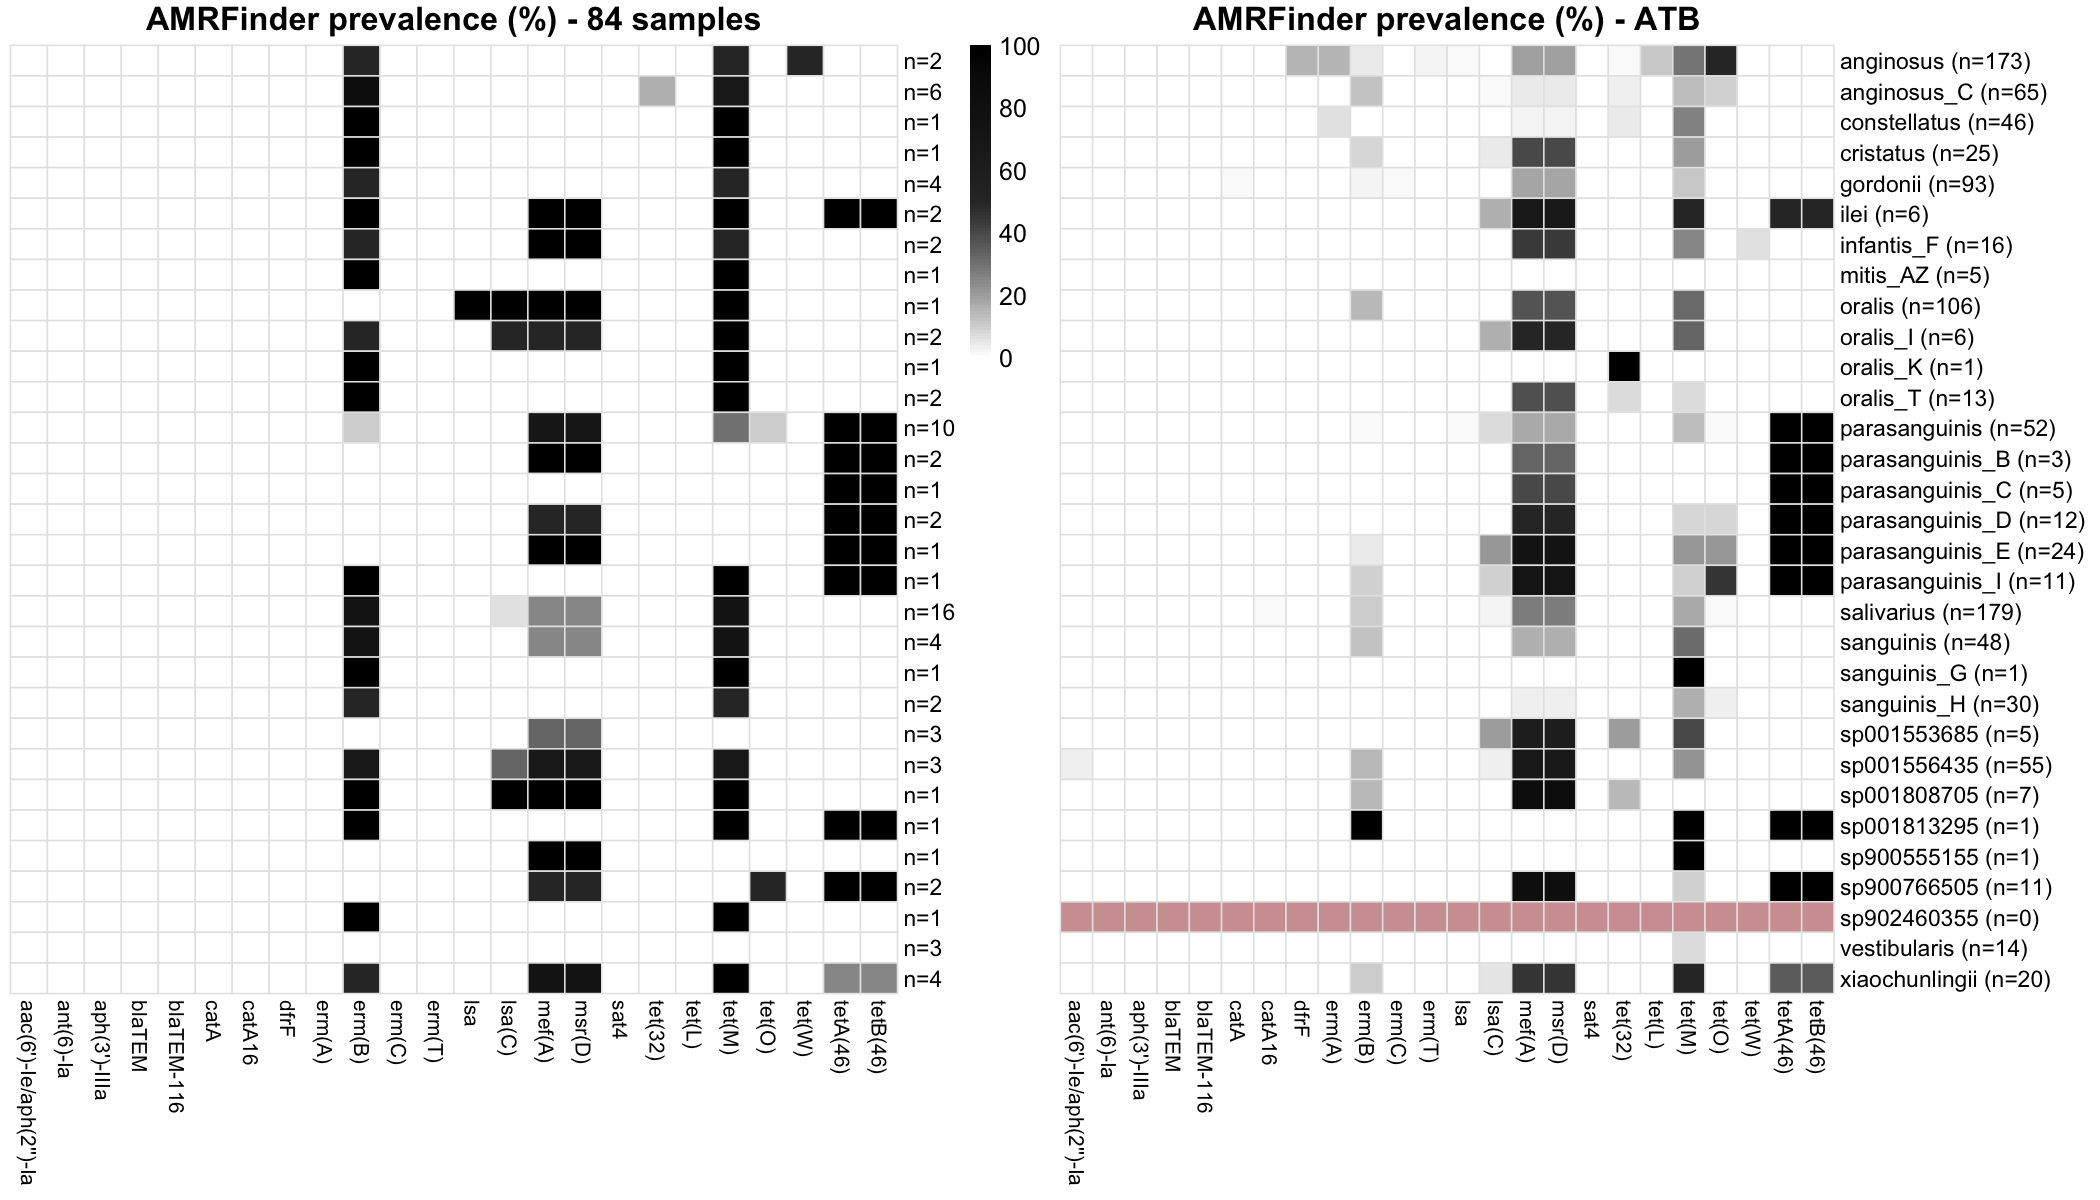

In [40]:
all_genomes_atb <- read_tsv("../results/atb/atb_genome_list.tsv", show_col_types = FALSE)

# strips run suffixes and leading zeros so IDs match across datasets
clean_id <- function(x) {
  x |>
    as.character() |>
    str_remove("-.*$") |>
    str_remove("^0+") |>
    str_to_lower()
}

# base table: one row per sample with a known GTDB species assignment
sample_species_base <- species_df |>
  mutate(sample_key = clean_id(SAMPLE_ID)) |>
  filter(!is.na(GTDB_214), GTDB_214 != "no species") |>
  distinct(sample_key, GTDB_214)

# join AMRFinder hits onto species table; samples with no hits are kept as NA rows
# so every genome is represented even if it carries no resistance genes
amr_species <- sample_species_base |>
  left_join(
    amr_clean |>
      select(sample, element_symbol, element_name) |>
      mutate(sample_key = clean_id(sample)),
    by = "sample_key"
  ) |>
  mutate(sample = coalesce(sample, sample_key))

# one data frame per species; drop the "no species" bin
amr_by_species <- split(amr_species, amr_species$GTDB_214)
amr_by_species <- amr_by_species[names(amr_by_species) != "no species"]

# ATB manifest: maps each public genome to its species label
atb_manifest <- all_genomes_atb |>
  transmute(species, sample = as.character(genome_id)) |>
  distinct()

# read one AMRFinder TSV per species from the ATB results folder
atb_amr_dir   <- "../results/atb/amrfinder_atb"
atb_amr_files <- list.files(atb_amr_dir, pattern = "^amrfinder_.*\\.tsv$", full.names = TRUE)

atb_amr_list <- purrr::map(atb_amr_files, \(f) {
  sp <- basename(f) |> str_remove("^amrfinder_") |> str_remove("\\.tsv$")

  df <- read_tsv(f, show_col_types = FALSE) |>
    rename(sample = Genome, element_symbol = `Element symbol`, element_name = `Element name`) |>
    transmute(sample = as.character(sample), element_symbol, element_name, source = "atb") |>
    distinct()

  # pad with NA rows for ATB genomes that had no hits, so n stays correct
  missing <- atb_manifest |>
    filter(species == sp, !sample %in% df$sample) |>
    transmute(sample, element_symbol = NA_character_, element_name = NA_character_, source = "atb")

  list(species = sp, data = bind_rows(df, missing) |> distinct())
})
names(atb_amr_list) <- purrr::map_chr(atb_amr_list, "species")

# label own samples before merging
amr_by_species <- purrr::map(amr_by_species, ~mutate(.x, source = "rmarvig"))

# merge own samples with ATB samples per species
# species present in own data but absent from ATB get an empty tibble
combined_amr <- purrr::map2(amr_by_species, names(amr_by_species), \(my_data, sp) {
  atb_data <- if (sp %in% names(atb_amr_list)) atb_amr_list[[sp]]$data else tibble()
  bind_rows(my_data, atb_data)
})

# union of all gene names seen across both sources — used as fixed column space
# so both heatmaps share the same gene axis and are directly comparable
global_gene_universe <- combined_amr |>
  purrr::map(~.x$element_symbol) |>
  unlist(use.names = FALSE) |>
  as.character() |>
  unique() |>
  (\(x) sort(x[!is.na(x) & x != ""]))()

# builds a species × gene matrix of % prevalence for a given source
# each cell = proportion of genomes in that species carrying that gene × 100
build_species_pct_matrix <- function(combined_amr, gene_universe, source_keep = c("rmarvig", "atb")) {

  # internal: binary presence/absence matrix for one species
  build_pa <- function(d, sample_ids, genes) {
    m <- matrix(0L, nrow = length(sample_ids), ncol = length(genes),
                dimnames = list(sample_ids, genes))
    hits <- d |>
      filter(!is.na(element_symbol), element_symbol != "") |>
      distinct(sample_id, gene = element_symbol)

    if (nrow(hits) > 0 && length(sample_ids) > 0) {
      rr   <- match(hits$sample_id, sample_ids)
      cc   <- match(hits$gene, genes)
      keep <- !is.na(rr) & !is.na(cc)
      if (any(keep)) m[cbind(rr[keep], cc[keep])] <- 1L
    }
    m
  }

  species <- sort(names(combined_amr))

  out <- purrr::map(species, \(sp) {
    df <- combined_amr[[sp]] |>
      filter(source %in% source_keep, !is.na(sample), sample != "") |>
      mutate(sample_id = as.character(sample))

    sids <- unique(df$sample_id)

    # species with no samples get NA row rather than zeros, flagged in red in the heatmap
    pct <- if (length(sids) == 0) rep(NA_real_, length(gene_universe)) else
             colMeans(build_pa(df, sids, gene_universe)) * 100

    list(sp = sp, n = length(sids),
         row = matrix(pct, nrow = 1, dimnames = list(sp, gene_universe)))
  })

  mat   <- do.call(rbind, purrr::map(out, "row"))
  n_tbl <- tibble(species = purrr::map_chr(out, "sp"), n = purrr::map_int(out, "n"))
  list(mat = mat, n_tbl = n_tbl)
}

# compute prevalence matrices separately for own samples and ATB reference
my_obj  <- build_species_pct_matrix(combined_amr, global_gene_universe, source_keep = "rmarvig")
atb_obj <- build_species_pct_matrix(combined_amr, global_gene_universe, source_keep = "atb")

hm_my  <- my_obj$mat
hm_atb <- atb_obj$mat

# restrict to species present in both so the two panels line up row-for-row
common_species <- intersect(rownames(hm_my), rownames(hm_atb))
hm_my  <- hm_my[common_species, , drop = FALSE]
hm_atb <- hm_atb[common_species, colnames(hm_my), drop = FALSE]

# own samples: show only n (species name already on the ATB panel next to it)
lab_my  <- paste0("n=", my_obj$n_tbl$n[match(common_species, my_obj$n_tbl$species)])
lab_atb <- paste0(common_species, " (n=", atb_obj$n_tbl$n[match(common_species, atb_obj$n_tbl$species)], ")")

brks <- seq(0, 100, length.out = 102)
cols <- colorRampPalette(c("white", "#313131", "black"))(101)

p1 <- pheatmap(
  hm_my,
  labels_row   = lab_my,
  cluster_rows = FALSE, cluster_cols = FALSE,
  color        = cols, breaks = brks, na_col = "#d1a0a0",
  border_color = "grey90", angle_col = 270,
  fontsize = 12, fontsize_row = 11, fontsize_col = 10,
  main   = "AMRFinder prevalence (%) - 84 samples",
  silent = TRUE
)

p2 <- pheatmap(
  hm_atb,
  labels_row   = lab_atb,
  cluster_rows = FALSE, cluster_cols = FALSE,
  color        = cols, breaks = brks, na_col = "#d1a0a0",
  border_color = "grey90", angle_col = 270,
  fontsize = 12, fontsize_row = 11, fontsize_col = 10,
  main   = "AMRFinder prevalence (%) - ATB",
  legend = FALSE, silent = TRUE  # legend shown only on left panel
)

options(repr.plot.width = 14, repr.plot.height = 8)
gridExtra::grid.arrange(p1$gtable, p2$gtable, ncol = 2, widths = c(1, 1))

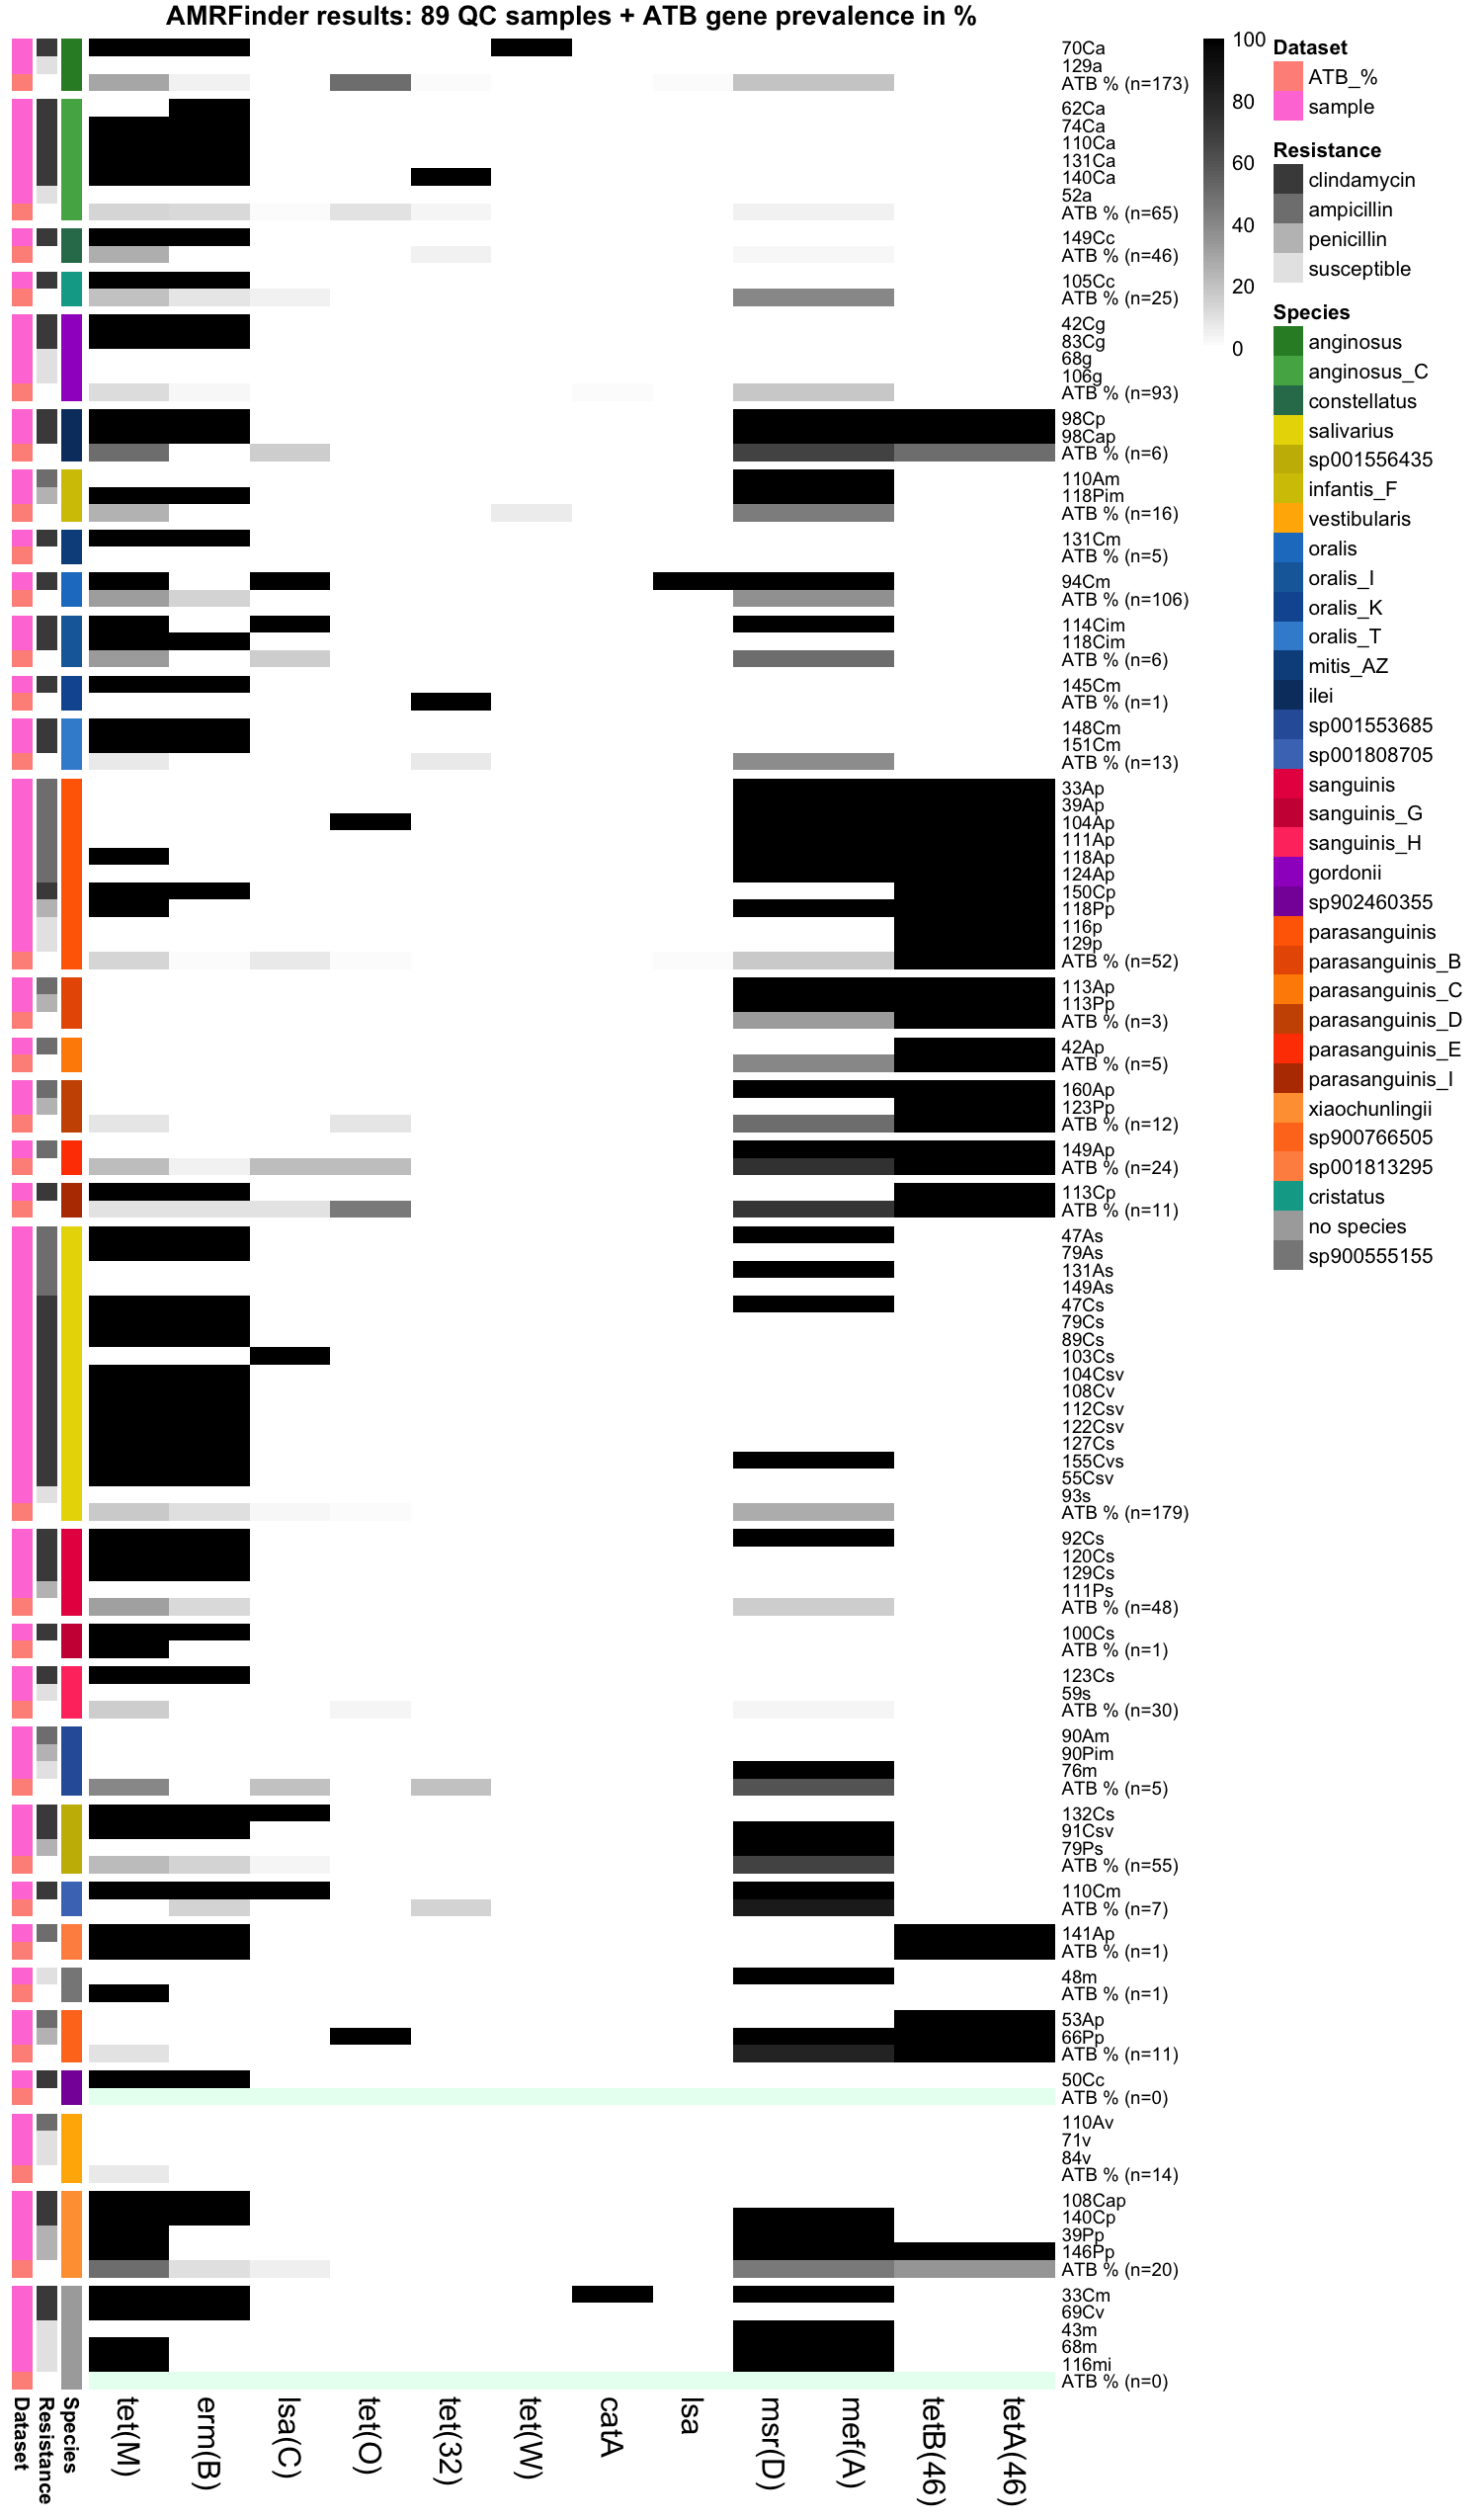

In [41]:
# colour palettes for MALDI species labels (pastel) and GTDB assignments (saturated)
maldi_colors <- c(
  "anginosus"     = "#B8E0B8",
  "constellatus"  = "#B8D4C8",
  "salivarius"    = "#f7f293",
  "vestibularis"  = "#fedc93",
  "mitis oralis"  = "#B8D4F0",
  "infantis"      = "#CCB8F0",
  "sanguinis"     = "#FFB8C8",
  "gordonii"      = "#E8B8E8",
  "parasanguinis" = "#fbb98c",
  "cristatus"     = "#B8EEE8"
)

# GTDB colours grouped by phylogenetic clade
gtdb_colors <- c(
  # anginosus group
  "anginosus"       = "#2E8B2E",
  "anginosus_C"     = "#52B052",
  "constellatus"    = "#2E7A5A",
  # salivarius group
  "salivarius"      = "#E8D800",
  "sp001556435"     = "#C8B800",
  "infantis_F"      = "#D4C400",
  "vestibularis"    = "#FFB300",
  # mitis / oralis M-clade
  "oralis"          = "#1E7EC8",
  "oralis_I"        = "#1A6AAA",
  "oralis_K"        = "#1458A0",
  "oralis_T"        = "#3D8FD4",
  "mitis_AZ"        = "#0D4F8C",
  "ilei"            = "#0A3D6E",
  "sp001553685"     = "#2E5FA8",
  "sp001808705"     = "#4A78C0",
  # sanguinis
  "sanguinis"       = "#E81050",
  "sanguinis_G"     = "#CC0D44",
  "sanguinis_H"     = "#FF3D6E",
  # gordonii
  "gordonii"        = "#A020C8",
  "sp902460355"     = "#8818A8",
  # parasanguinis S-clade
  "parasanguinis"   = "#FF6A00",
  "parasanguinis_B" = "#E85A00",
  "parasanguinis_C" = "#FF8C00",
  "parasanguinis_D" = "#CC5500",
  "parasanguinis_E" = "#FF4500",
  "parasanguinis_I" = "#B83C00",
  "xiaochunlingii"  = "#FFA040",
  "sp900766505"     = "#FF7820",
  "sp001813295"     = "#FF9050",
  # cristatus
  "cristatus"       = "#00A896",
  # unresolved
  "no species"      = "#AAAAAA",
  "sp900555155"     = "#888888"
)

# legend display order
maldi_order <- c("anginosus", "constellatus", "salivarius", "vestibularis",
                 "mitis oralis", "infantis", "sanguinis", "gordonii",
                 "parasanguinis", "cristatus")

gtdb_order <- c(
  "anginosus", "anginosus_C",
  "constellatus",
  "salivarius", "sp001556435", "infantis_F", "vestibularis",
  "oralis", "oralis_I", "oralis_K", "oralis_T", "mitis_AZ",
  "ilei", "sp001553685", "sp001808705",
  "sanguinis", "sanguinis_G", "sanguinis_H",
  "gordonii", "sp902460355",
  "parasanguinis", "parasanguinis_B", "parasanguinis_C", "parasanguinis_D",
  "parasanguinis_E", "parasanguinis_I", "xiaochunlingii", "sp900766505", "sp001813295",
  "cristatus",
  "no species", "sp900555155"
)

options(repr.plot.width = 10, repr.plot.height = 17, repr.plot.res = 150)

# sample annotation: replace NAs with explicit labels so every row is annotated
annot <- species_df |>
  select(SAMPLE_ID, GTDB_214) |>
  left_join(df_filtered |> select(SAMPLE_ID, Resistance), by = "SAMPLE_ID") |>
  transmute(
    SAMPLE_ID,
    Species    = dplyr::coalesce(GTDB_214, "no species"),
    Resistance = dplyr::coalesce(Resistance, "susceptible")
  ) |>
  distinct(SAMPLE_ID, .keep_all = TRUE)

all_sample_ids <- annot$SAMPLE_ID

# AMRFinder presence/absence matrix (1 = gene detected)
pa_mat_amr <- amr_clean |>
  filter(!is.na(element_symbol)) |>
  mutate(sample_short = sub("-.*", "", sample) |> sub("^0+", "", x = _)) |>
  distinct(sample_short, element_symbol) |>
  mutate(present = 1L) |>
  pivot_wider(names_from = element_symbol, values_from = present, values_fill = 0L) |>
  (\(d) tibble(sample_short = all_sample_ids) |>
    left_join(d, by = "sample_short") |>
    mutate(across(-sample_short, ~replace_na(as.integer(.x), 0L))))() |>
  column_to_rownames("sample_short") |>
  as.matrix()

# sort rows: "no species" last, then alphabetically by species, then by resistance
annot_sorted_clean_amr <- annot |>
  filter(SAMPLE_ID %in% rownames(pa_mat_amr)) |>
  arrange(Species == "no species", Species, Resistance) |>
  column_to_rownames("SAMPLE_ID") |>
  mutate(Resistance = str_remove(Resistance, "_resistant") |> str_to_lower())

sorted_order_amr <- rownames(annot_sorted_clean_amr)
pa_mat_amr <- pa_mat_amr[sorted_order_amr, , drop = FALSE]

# scale 0/1 to 0/100 so sample rows share the same colour axis as ATB % rows
sample_mat_100 <- pa_mat_amr * 100

# returns the ATB gene prevalence (%) for one species across a fixed gene set
build_atb_pct_row <- function(sp, genes, atb_amr_list) {
  if (!(sp %in% names(atb_amr_list))) return(list(values = rep(NA_real_, length(genes)), n = 0L))

  df <- atb_amr_list[[sp]]$data |>
    filter(!is.na(sample), sample != "") |>
    mutate(sample_id = as.character(sample))

  sample_ids <- unique(df$sample_id)
  if (length(sample_ids) == 0) return(list(values = rep(NA_real_, length(genes)), n = 0L))

  m <- matrix(0L, nrow = length(sample_ids), ncol = length(genes),
              dimnames = list(sample_ids, genes))

  hits <- df |>
    filter(!is.na(element_symbol), element_symbol != "") |>
    distinct(sample_id, gene = element_symbol)

  rr   <- match(hits$sample_id, sample_ids)
  cc   <- match(hits$gene, genes)
  keep <- !is.na(rr) & !is.na(cc)
  if (any(keep)) m[cbind(rr[keep], cc[keep])] <- 1L

  list(values = colMeans(m) * 100, n = length(sample_ids))
}

species_order <- unique(annot_sorted_clean_amr$Species)
genes_order   <- colnames(sample_mat_100)

# interleave sample rows and one ATB % summary row per species
hm_parts     <- list()
ann_parts    <- list()
group_sizes  <- integer(length(species_order))
row_labels   <- character()

for (i in seq_along(species_order)) {
  sp           <- species_order[i]
  sample_rows  <- rownames(annot_sorted_clean_amr)[annot_sorted_clean_amr$Species == sp]

  hm_parts[[length(hm_parts) + 1]]  <- sample_mat_100[sample_rows, , drop = FALSE]
  ann_parts[[length(ann_parts) + 1]] <- annot_sorted_clean_amr[sample_rows, , drop = FALSE] |>
    mutate(Dataset = "sample")
  row_labels <- c(row_labels, sample_rows)

  # ATB % summary row appended after each species block
  atb_info   <- build_atb_pct_row(sp, genes_order, atb_amr_list)
  atb_row_id <- paste0("__ATB__", sp)

  hm_parts[[length(hm_parts) + 1]] <- matrix(
    atb_info$values, nrow = 1,
    dimnames = list(atb_row_id, genes_order)
  )
  ann_parts[[length(ann_parts) + 1]] <- data.frame(
    Species = sp, Resistance = NA_character_, Dataset = "ATB_%",
    row.names = atb_row_id
  )
  row_labels  <- c(row_labels, paste0("ATB % (n=", atb_info$n, ")"))
  group_sizes[i] <- length(sample_rows) + 1L
}

hm_combined  <- do.call(rbind, hm_parts)
ann_combined <- do.call(rbind, ann_parts)

# gap after each species block (excluding the last)
gaps_combined <- cumsum(group_sizes)[-length(group_sizes)]

ann_colors <- list(
  Species    = gtdb_colors,
  Resistance = c(
    clindamycin = "#4A4A4A",
    ampicillin  = "#808080",
    penicillin  = "#BFBFBF",
    susceptible = "#E6E6E6"
  )
)

heatmap_args <- list(
  mat               = hm_combined,
  labels_row        = row_labels,
  annotation_row    = ann_combined,
  annotation_colors = ann_colors,
  cluster_rows      = FALSE,
  cluster_cols      = TRUE,
  treeheight_col    = 0,
  gaps_row          = gaps_combined,
  color             = colorRampPalette(c("white", "#808080", "black"))(101),
  breaks            = seq(0, 100, length.out = 102),
  na_col            = "#e8fff1",
  angle_col         = 270,
  main              = "AMRFinder results: 89 QC samples + ATB gene prevalence in %"
)

# interactive display
do.call(pheatmap::pheatmap, c(heatmap_args, list(
  border_color = "grey85",
  fontsize_row = 9,
  fontsize_col = 15
)))

# high-res PDF export with fixed cell dimensions
do.call(pheatmap::pheatmap, c(heatmap_args, list(
  border_color = "black",
  cellwidth    = 20,
  cellheight   = 10,
  fontsize_row = 8,
  fontsize_col = 12,
  filename     = "figures/amr_heatmap_borders.pdf",
  width        = 20,
  height       = 24
)))

#### Pangenome and taxonomy analysis

$n_genomes
[1] 89

$n_genes_total
[1] 18768

$core_genes
[1] 65

$accessory_genes
[1] 13403

$unique_genes
[1] 5300

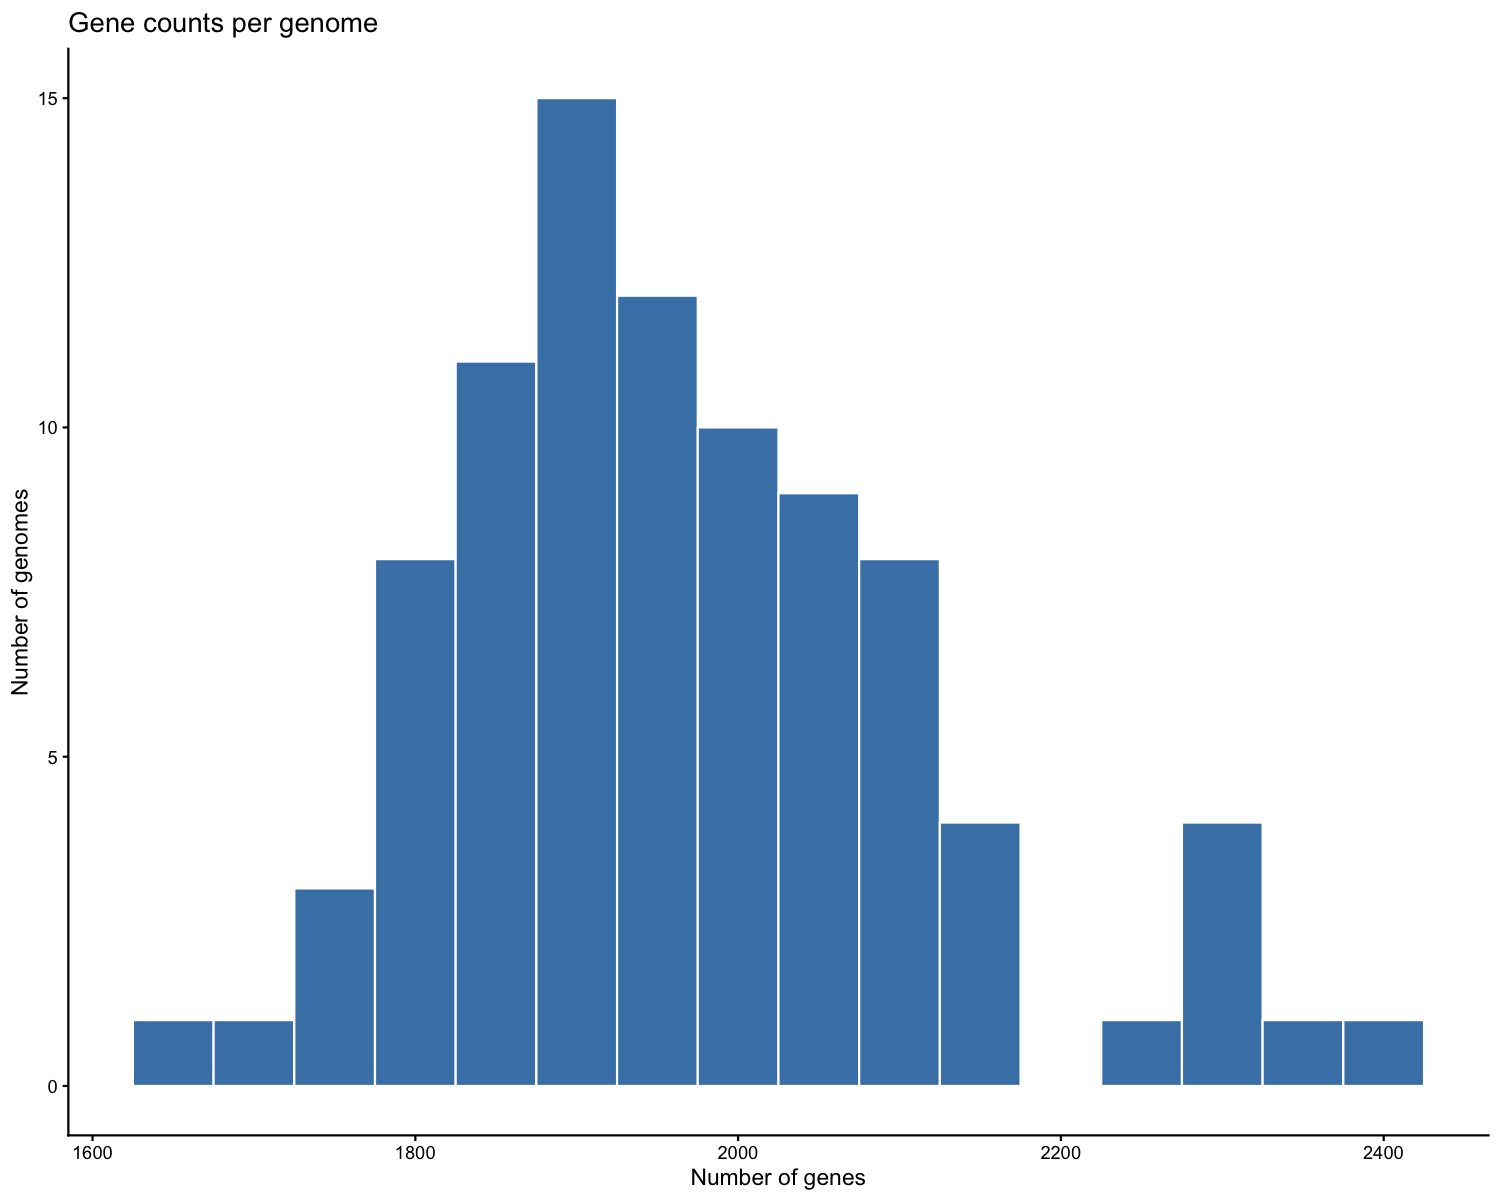

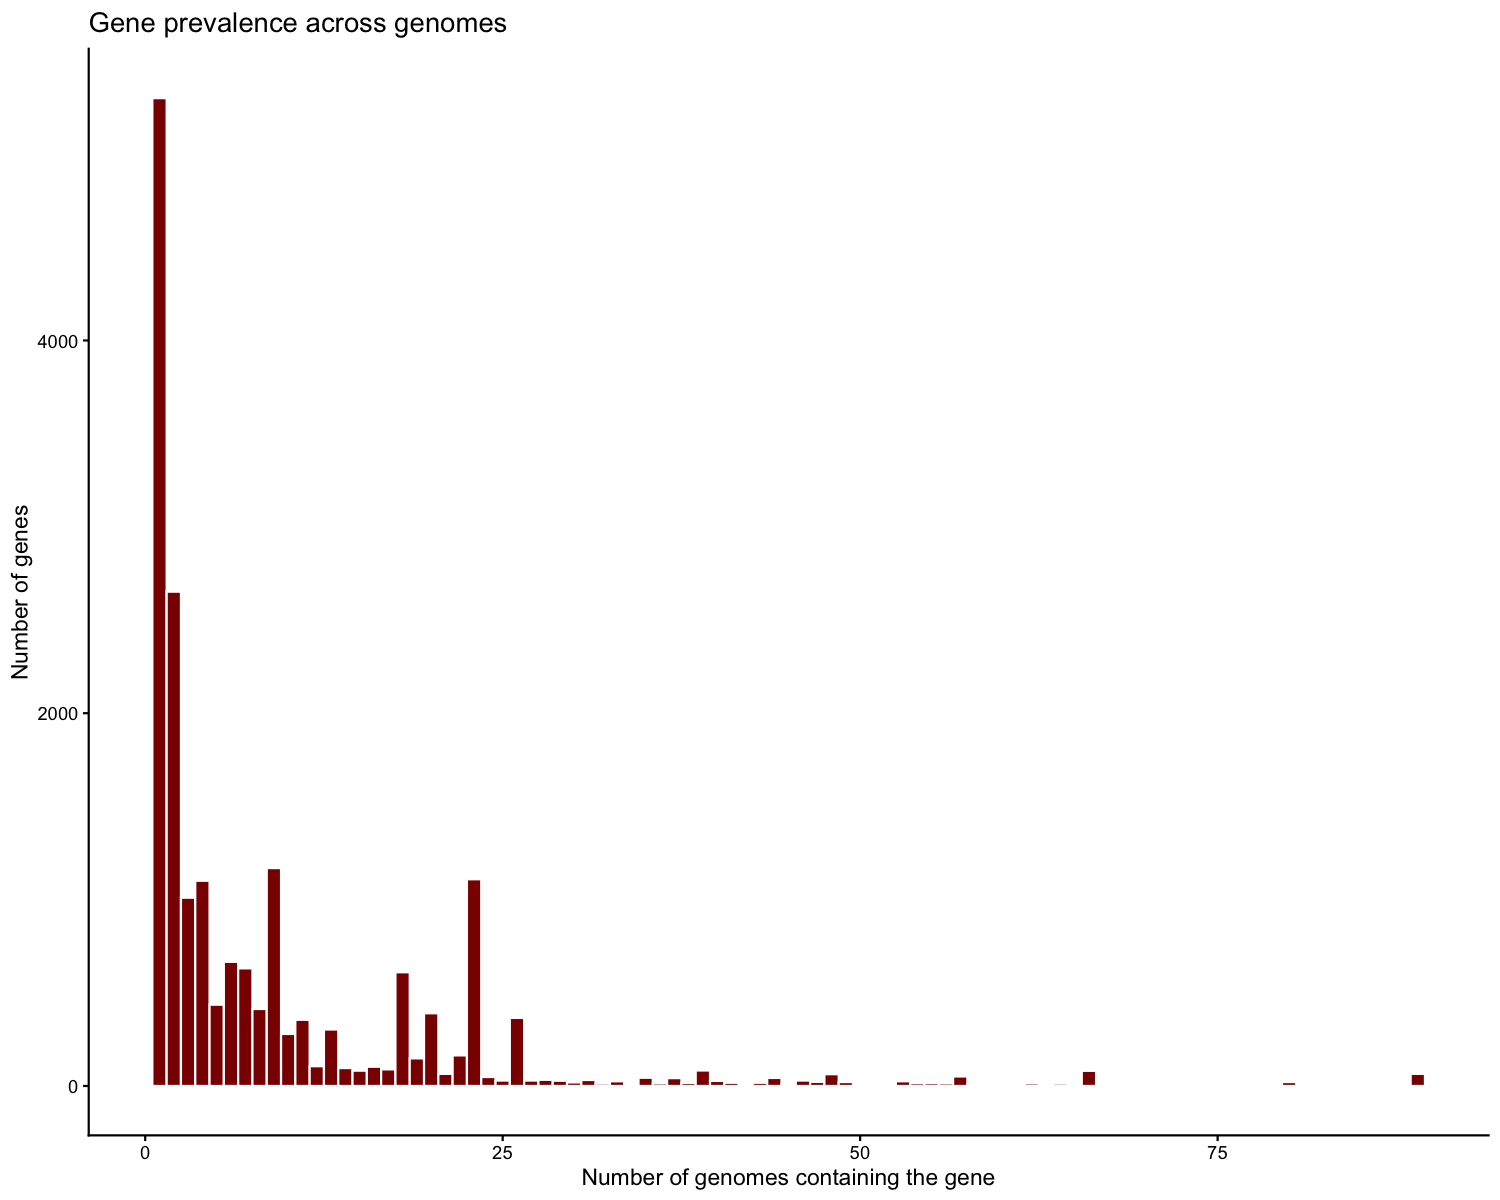

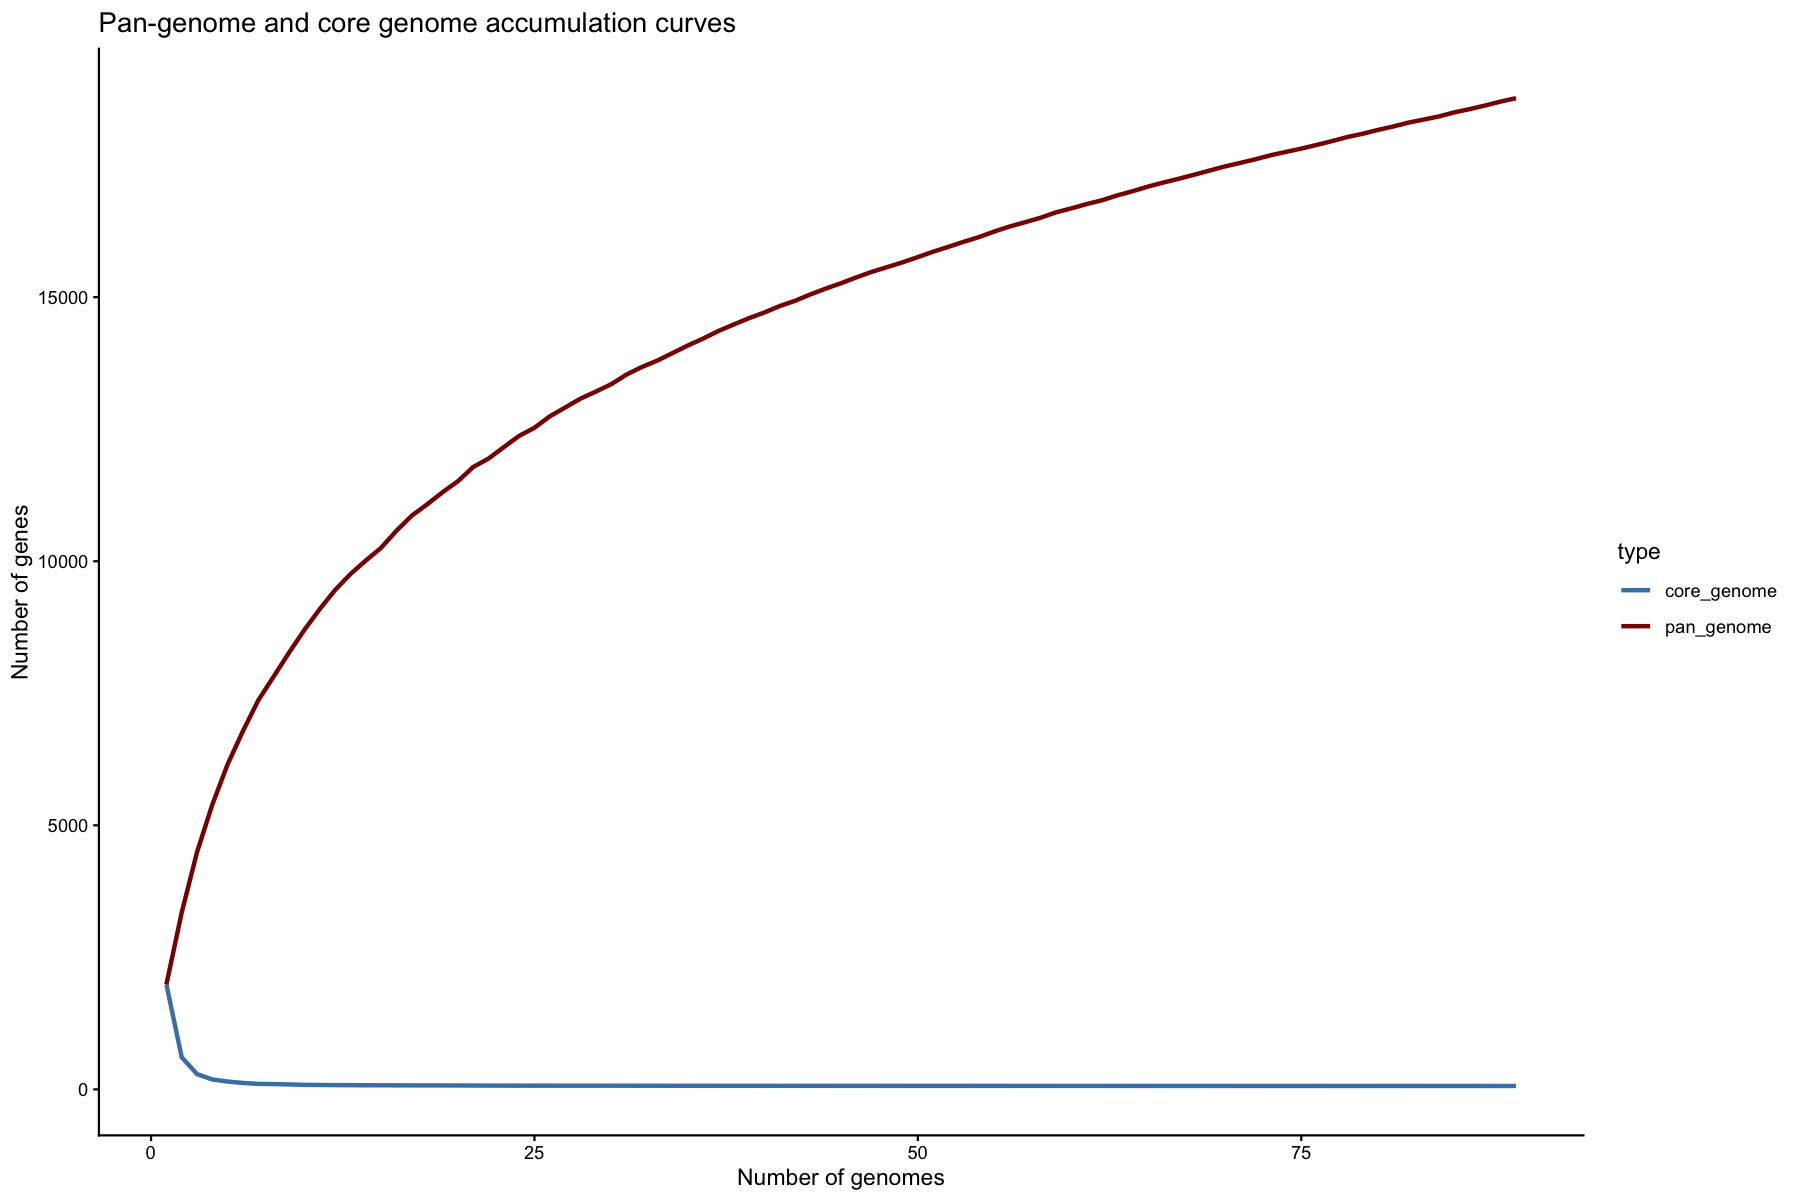

In [42]:
# pangenome gene presence/absence matrix
pan <- read.table("../results/pangenome/gene_presence_absence.Rtab",
                  header = TRUE, row.names = 1, sep = "\t")

pan_binary <- as.matrix(pan > 0)

# gene counts per genome and genome counts per gene
gene_count_df <- tibble(
  sample     = colnames(pan_binary),
  gene_count = colSums(pan_binary) |> as.integer()
)

gene_prevalence_df <- tibble(
  gene      = rownames(pan_binary),
  n_genomes = rowSums(pan_binary) |> as.integer()
)

# core = in all genomes, accessory = in >1 but not all, unique = in exactly 1
genomes_per_gene <- rowSums(pan_binary)
n_genomes        <- ncol(pan_binary)

list(
  n_genomes       = n_genomes,
  n_genes_total   = nrow(pan_binary),
  core_genes      = sum(genomes_per_gene == n_genomes),
  accessory_genes = sum(genomes_per_gene > 1 & genomes_per_gene < n_genomes),
  unique_genes    = sum(genomes_per_gene == 1)
)

options(repr.plot.width = 10, repr.plot.height = 8)

ggplot(gene_count_df, aes(x = gene_count)) +
  geom_histogram(binwidth = 50, fill = "steelblue", color = "white") +
  labs(title = "Gene counts per genome",
       x = "Number of genes", y = "Number of genomes") +
  theme_classic()

ggplot(gene_prevalence_df, aes(x = n_genomes)) +
  geom_histogram(binwidth = 1, fill = "darkred", color = "white") +
  labs(title = "Gene prevalence across genomes",
       x = "Number of genomes containing the gene", y = "Number of genes") +
  theme_classic()


# rarefaction: accumulate pan- and core-genome size as genomes are added one by one
# averaged over n_perms random genome orderings to smooth out sampling noise
set.seed(42)
n_perms  <- 100
pan_size  <- numeric(ncol(pan_binary))
core_size <- numeric(ncol(pan_binary))

for (i in seq_len(n_perms)) {
  order <- sample(ncol(pan_binary))
  for (j in seq_along(order)) {
    sub <- pan_binary[, order[1:j], drop = FALSE]
    pan_size[j]  <- pan_size[j]  + sum(rowSums(sub) >= 1)
    core_size[j] <- core_size[j] + sum(rowSums(sub) == j)
  }
}

curve_df <- tibble(
  n_genomes   = seq_len(ncol(pan_binary)),
  pan_genome  = pan_size  / n_perms,
  core_genome = core_size / n_perms
) |>
  pivot_longer(-n_genomes, names_to = "type", values_to = "genes")

options(repr.plot.width = 12, repr.plot.height = 8)

ggplot(curve_df, aes(x = n_genomes, y = genes, color = type)) +
  geom_line(linewidth = 1) +
  scale_color_manual(values = c(pan_genome = "darkred", core_genome = "steelblue")) +
  labs(
    title = "Pan-genome and core genome accumulation curves",
    x     = "Number of genomes",
    y     = "Number of genes"
  ) +
  theme_classic()

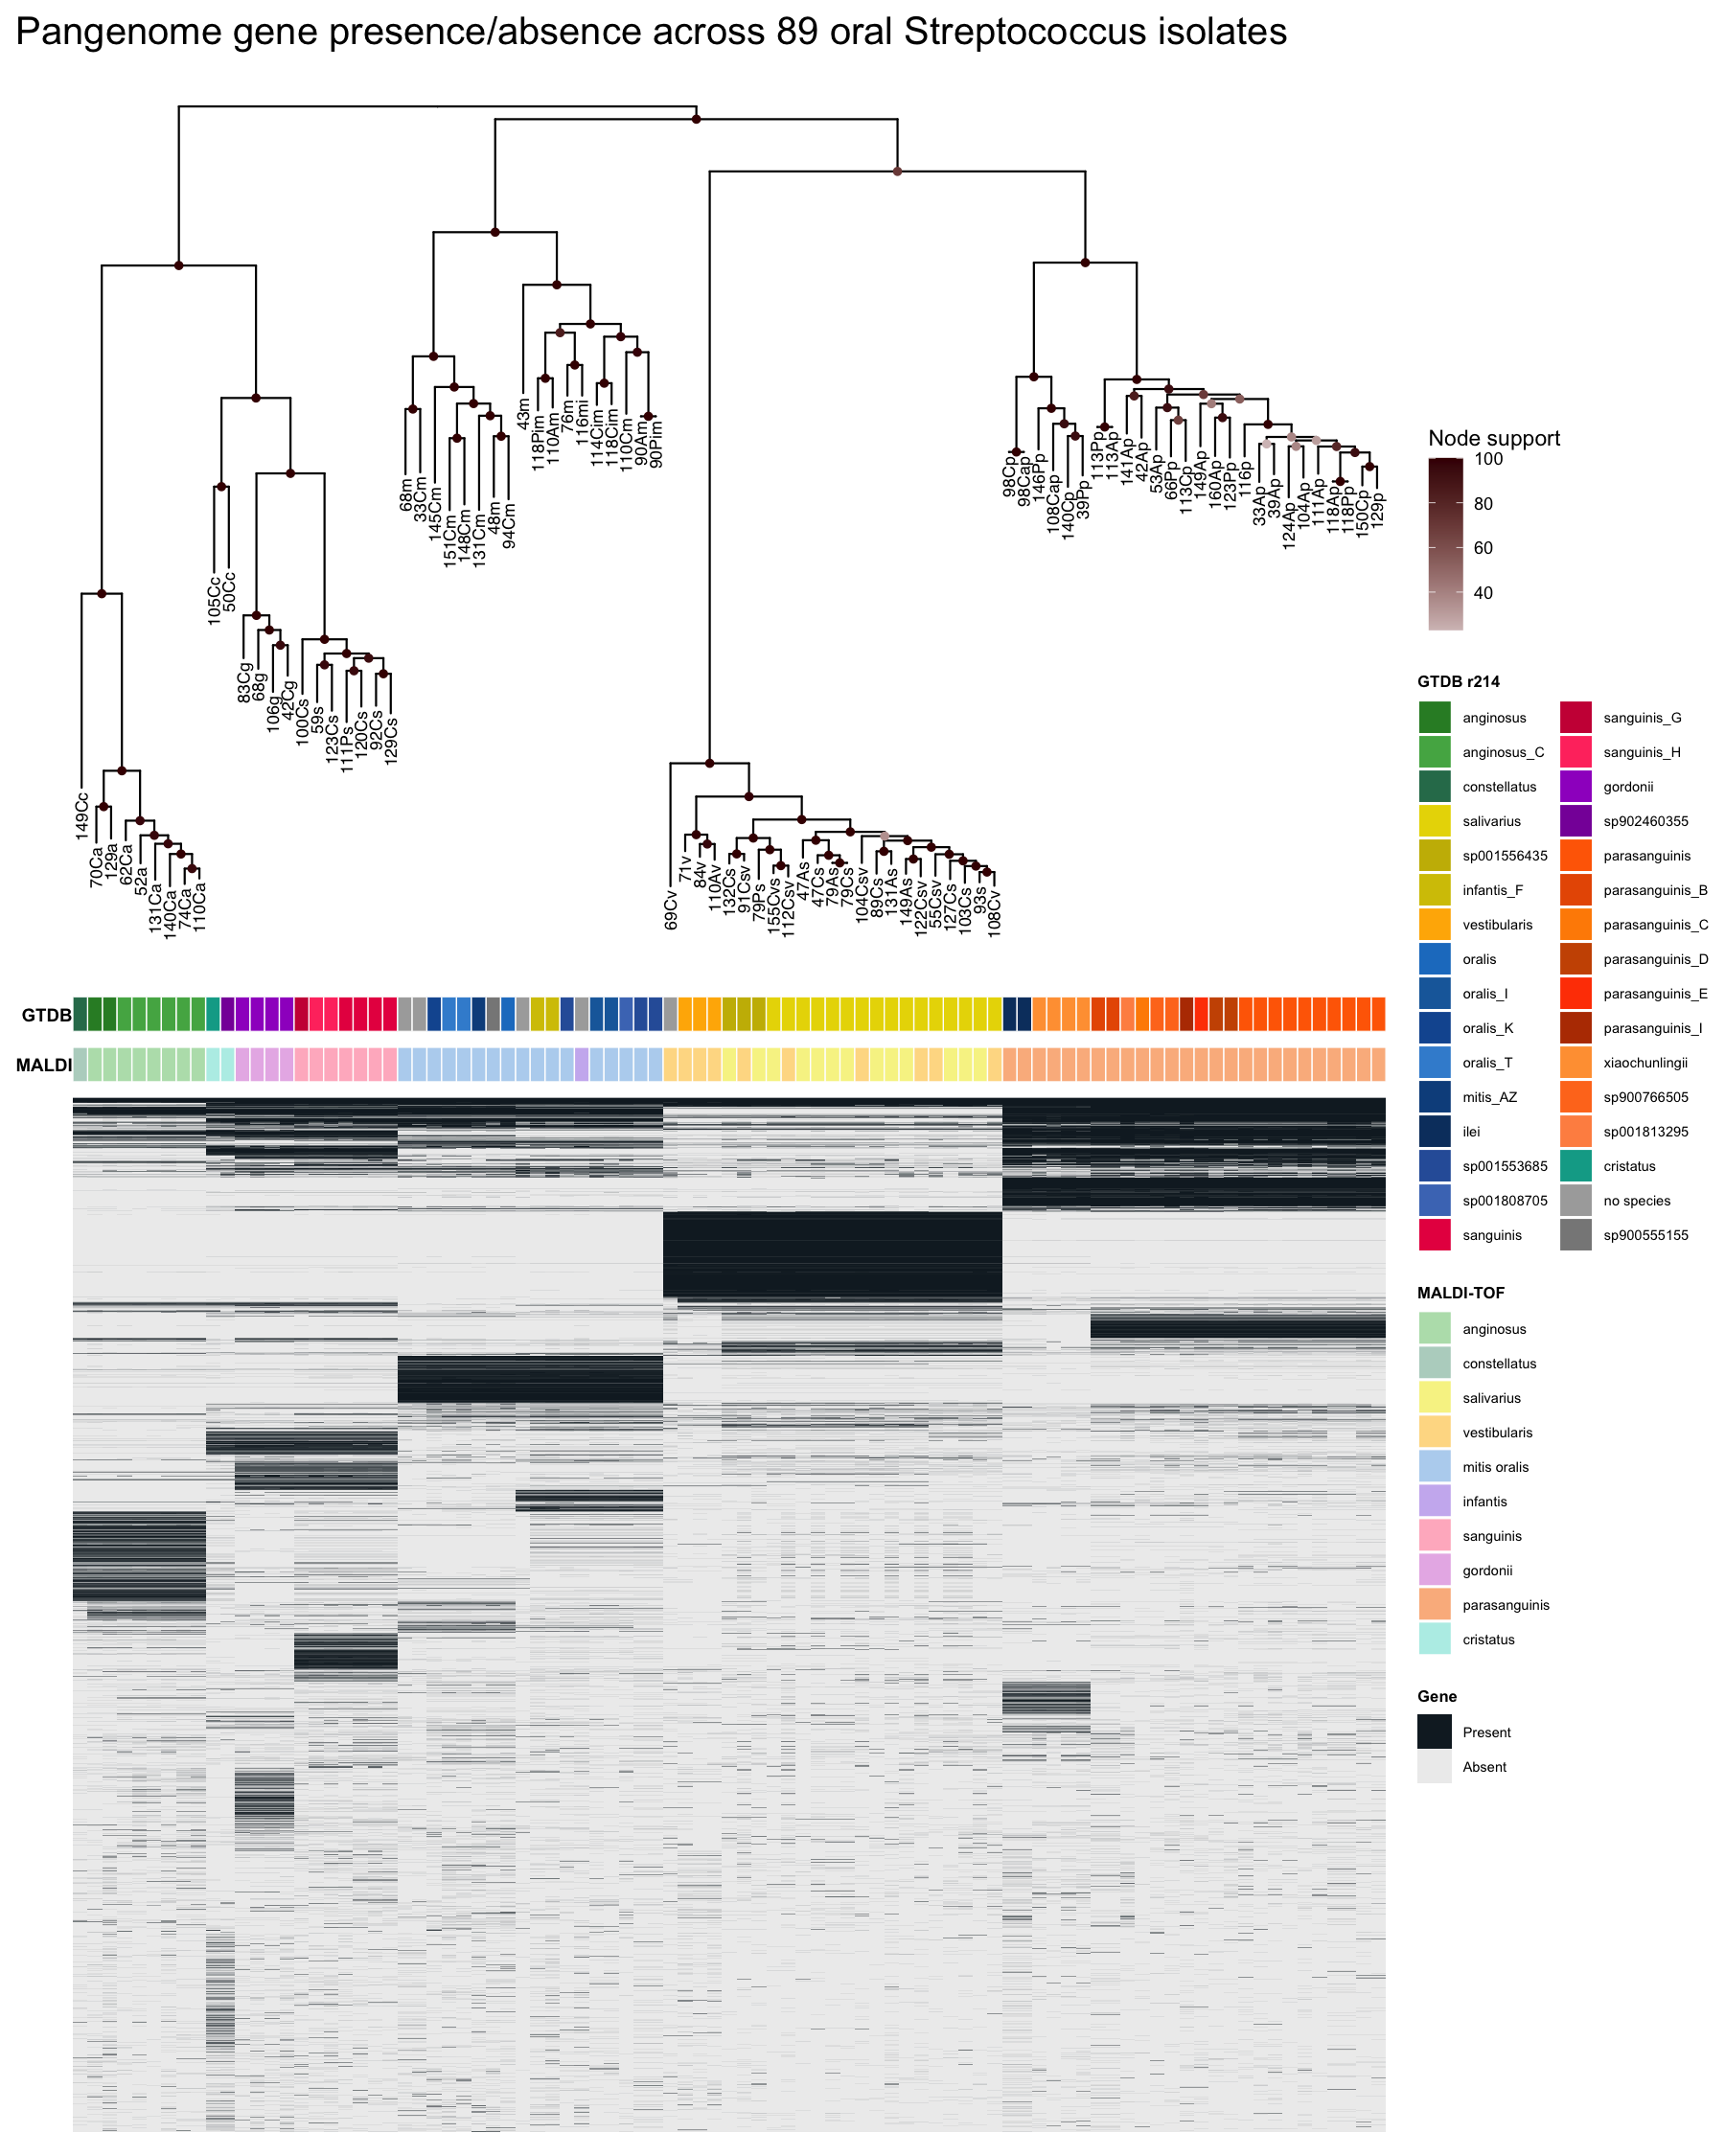

In [ ]:
# load tree and pangenome data
tree <- read.tree("../results/pangenome/strep_core_tree.treefile")
pan  <- read.table("../results/pangenome/gene_presence_absence.Rtab",
                   header = TRUE, row.names = 1, sep = "\t")

# midpoint root and clean tip labels
tree <- midpoint.root(tree)
tree$tip.label <- sub("[-_].*$", "", tree$tip.label)
tree$tip.label <- sub("^0+",     "", tree$tip.label)

# annotation (no resistance column needed here)
annot <- species_df |> select(-Resistance)

# clean pangenome column names
clean_pan_names <- function(x) {
  x <- sub("^X0*", "", x)
  x <- sub("\\..*$", "", x)
  x
}
colnames(pan) <- clean_pan_names(colnames(pan))

# tip order 
# build a cladogram silently just to extract the tip order used by patchwork
p_base_clado <- ggtree(tree, layout = "rectangular", branch.length = "none") %<+% annot +
  layout_dendrogram()

tip_order_clado <- rev(get_taxa_name(p_base_clado))

annot_ordered_clado <- annot |>
  filter(SAMPLE_ID %in% tip_order_clado) |>
  mutate(label = factor(SAMPLE_ID, levels = tip_order_clado))

# species annotation tiles 
p_gtdb_clado <- ggplot(annot_ordered_clado, aes(x = label, y = 1, fill = GTDB_214)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual("GTDB r214", values = gtdb_colors, breaks = gtdb_order, na.value = "white") +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_continuous(expand = c(0, 0)) +
  labs(y = "GTDB") +
  theme_void() +
  theme(
    axis.title.y  = element_text(size = 9, angle = 0, vjust = 0.5, hjust = 1, face = "bold"),
    legend.position = "right",
    legend.text   = element_text(size = 7),
    legend.title  = element_text(size = 8, face = "bold"),
    plot.margin   = margin(4, 0, 4, 0)
  )

p_maldi_clado <- ggplot(annot_ordered_clado, aes(x = label, y = 1, fill = Maldi_2)) +
  geom_tile(color = "white", linewidth = 0.3) +
  scale_fill_manual("MALDI-TOF", values = maldi_colors, breaks = maldi_order, na.value = "white") +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_continuous(expand = c(0, 0)) +
  labs(y = "MALDI") +
  theme_void() +
  theme(
    axis.title.y  = element_text(size = 9, angle = 0, vjust = 0.5, hjust = 1, face = "bold"),
    legend.position = "right",
    legend.text   = element_text(size = 7),
    legend.title  = element_text(size = 8, face = "bold"),
    plot.margin   = margin(4, 0, 4, 0)
  )

# phylogenetic tree (branch lengths, node support colored) 
p_base <- ggtree(tree, layout = "rectangular") %<+% annot +
  layout_dendrogram()

p_tree <- p_base +
  geom_point2(
    aes(
      color  = suppressWarnings(as.numeric(label)),
      subset = !is.na(suppressWarnings(as.numeric(label)))
    ),
    size = 1.5
  ) +
  scale_color_gradient(name = "Node support", low = "#d4c0c0", high = "#420101") +
  geom_tiplab(aes(label = label), angle = 90, hjust = 1, size = 3) +
  theme(plot.margin = margin(0, 0, 30, 0))

# pangenome heatmap (core + accessory, no unique genes) 
pan_no_unique <- pan[rowSums(pan > 0) > 1, , drop = FALSE]

pan_long_no_unique <- pan_no_unique |>
  as.data.frame() |>
  rownames_to_column("gene") |>
  pivot_longer(-gene, names_to = "sample", values_to = "present") |>
  mutate(
    sample  = factor(sample, levels = tip_order_clado),
    gene    = factor(gene, levels = rev(unique(gene))),
    present = factor(present, levels = c(1, 0))
  ) |>
  filter(!is.na(sample))

p_pan_clado_no_unique <- ggplot(pan_long_no_unique, aes(x = sample, y = gene, fill = present)) +
  geom_tile(linewidth = 0) +
  scale_fill_manual(
    "Gene",
    values = c("1" = "#14212b", "0" = "grey93"),
    labels = c("1" = "Present", "0" = "Absent"),
    na.value = "white"
  ) +
  scale_x_discrete(expand = c(0, 0)) +
  scale_y_discrete(expand = c(0, 0)) +
  labs(y = "") +
  theme_void() +
  theme(
    axis.title.y  = element_text(size = 9, angle = 0, vjust = 0.5, hjust = 1, face = "bold"),
    axis.text.y   = element_blank(),
    legend.position = "right",
    legend.text   = element_text(size = 7),
    legend.title  = element_text(size = 8, face = "bold"),
    plot.margin   = margin(4, 0, 4, 0)
  )

# combined plot 
options(repr.plot.width = 12, repr.plot.height = 15)

p_combined <- p_tree / p_gtdb_clado / p_maldi_clado / p_pan_clado_no_unique +
  plot_layout(heights = c(0.25, 0.01, 0.01, 0.3), guides = "collect") &
  theme(legend.position = "right")

p_combined +
  plot_annotation(title = "Pangenome gene presence/absence across 89 oral Streptococcus isolates")